In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch



Load ERA5/Obs data

In [2]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('../data_ready/7_with_VB.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('../data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('../data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('../data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.4348 -0.7162 1.351 ... 1.365 1.083 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Late'

Load Hindcast data

In [3]:
path='/climca/people/glattus/Hindcast_data_ready/'
ds_Andes_SON=xr.open_dataset(path+'Target_vars_Andes_SON.nc')
ds_Andes_DJF=xr.open_dataset(path+'Target_vars_Andes_DJF.nc')

def drop_duplicates(ds, sep_init=False):
    if sep_init==False:
        ds = ds.sortby(["forecast_reference_time", "number", "init_month"])
        ds = ds.drop_duplicates(dim="sample")
    else:
        ds = ds.sortby(["forecast_reference_time", "number"])
        ds = ds.drop_duplicates(dim="sample")
    return ds

#function for excluding ssw years
def exclude_years(ds, years_list=[2002,2019]):
    years = ds.forecast_reference_time.dt.year

    keep = ~years.isin(years_list)

    return ds.isel(sample=keep)

ds_Andes_SON=drop_duplicates(ds_Andes_SON)
ds_Andes_DJF=drop_duplicates(ds_Andes_DJF)

ds_Andes_SON=exclude_years(ds_Andes_SON, years_list=[2002,2019])
ds_Andes_DJF=exclude_years(ds_Andes_DJF, years_list=[2003,2020])

ds_LP_SON=xr.open_dataset(path+'Target_vars_LP_SON.nc')
ds_LP_DJF=xr.open_dataset(path+'Target_vars_LP_DJF.nc')

ds_LP_SON=drop_duplicates(ds_LP_SON)
ds_LP_DJF=drop_duplicates(ds_LP_DJF)

ds_LP_SON=exclude_years(ds_LP_SON, years_list=[2002,2019])
ds_LP_DJF=exclude_years(ds_LP_DJF, years_list=[2003,2020])

display(ds_LP_SON.sizes)
display(ds_LP_SON)

Frozen({'sample': 32640})

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 32640)
Coordinates:
    lead_block               <U9 36B ...
    init_month               (sample) int64 261kB ...
    season                   (sample) <U3 392kB ...
    forecast_reference_time  (sample) datetime64[ns] 261kB 1981-06-01 ... 202...
    number                   (sample) int64 261kB ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 261kB ...
    tp                       (sample) float64 261kB ...

In [4]:
ds_strato_SON=xr.open_dataset(path+'SPV_SON.nc')
#ds_strato_DJF=xr.open_dataset(path+'SPV_DJF.nc')

ds_strato_SON=drop_duplicates(ds_strato_SON)
#ds_strato_DJF=drop_duplicates(ds_strato_DJF)

ds_strato_SON=exclude_years(ds_strato_SON, years_list=[2002,2019])

Bootstrap hindcast data from the different ensembles

In [5]:
ds_Andes_SON.sizes

Frozen({'sample': 32640})

In [6]:
test = ds_Andes_SON['t2m'].where(
    (ds_Andes_SON["forecast_reference_time"] == '1987-09-01T00:00:00.000000000') &
    (ds_Andes_SON["number"] == 1) &
    (ds_Andes_SON["init_month"] ==  9)
)
#1987-09-01T00:00:00.000000000 28 lead_4_5_6
print(test)

<xarray.DataArray 't2m' (sample: 32640)> Size: 261kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(32640,))
Coordinates:
    lead_block               <U9 36B 'SON_block'
    init_month               (sample) int64 261kB 6 7 8 9 6 7 8 ... 8 9 6 7 8 9
    season                   (sample) <U3 392kB 'SON' 'SON' ... 'SON' 'SON'
    forecast_reference_time  (sample) datetime64[ns] 261kB 1981-06-01 ... 202...
    number                   (sample) int64 261kB 0 0 0 0 1 1 ... 49 50 50 50 50
Dimensions without coordinates: sample


In [7]:
len_boot=len(era_DJF_Andes_array.year)
print(len_boot)

73


In [8]:
def generate_samples(ds, var, len_boot=None, seed=None):

    rng = np.random.default_rng(seed)

    da = ds[var]

    # --------------------------------------------------
    # Get forecast year for every sample
    # --------------------------------------------------

    years = da.forecast_reference_time.dt.year.values
    unique_years = np.unique(years)

    # Number of years to include in each bootstrap realization
    if len_boot is None:
        len_boot = len(unique_years)

    # --------------------------------------------------
    # Resample YEARS with replacement
    # --------------------------------------------------

    selected_years = rng.choice(
        unique_years,
        size=len_boot,
        replace=True
    )

    # --------------------------------------------------
    # Keep ALL ensemble members / init months belonging
    # to each selected year
    # --------------------------------------------------

    samples = []

    for year in selected_years:

        year_mask = years == year

        values = da.values[year_mask]

        values = values[np.isfinite(values)]

        samples.extend(values)

    return np.asarray(samples)

def generate_samples_fixed_init_month(
    ds,
    var,
    len_boot=None,
    seed=42
):

    rng = np.random.default_rng(seed)

    da = ds[var]

    months = np.unique(
        da.init_month.values
    )

    samples = []

    for month in months:

        da_month = da.sel(
            init_month=month
        )

        years = (
            da_month
            .forecast_reference_time
            .dt.year
            .values
        )

        unique_years = np.unique(years)

        if len_boot is None:
            n_years = len(unique_years)
        else:
            n_years = len_boot

        # ----------------------------------------------
        # Bootstrap years
        # ----------------------------------------------

        selected_years = rng.choice(
            unique_years,
            size=n_years,
            replace=True
        )

        month_samples = []

        # ----------------------------------------------
        # Retain all ensemble members for each year
        # ----------------------------------------------

        for year in selected_years:

            year_mask = years == year

            values = da_month.values[year_mask]

            values = values[np.isfinite(values)]

            month_samples.extend(values)

        samples.append(
            np.asarray(month_samples)
        )

    return samples

def bootstrap_chain(
    ds,
    iterations,
    var,
    sep_lead=False,
    len_boot=None,
    seed=42
):

    rng = np.random.default_rng(seed)

    if sep_lead == False:

        return [
            generate_samples(
                ds,
                var,
                len_boot=len_boot,
                seed=rng.integers(0, 1_000_000_000)
            )
            for _ in range(iterations)
        ]

    else:

        return [
            generate_samples_fixed_init_month(
                ds,
                var,
                len_boot=len_boot,
                seed=rng.integers(0, 1_000_000_000)
            )
            for _ in range(iterations)
        ]


def model_eval_plot(
    boot_samples,
    era5_array,
    input_title,
    ds_init=None
):

    q = np.linspace(0.01, 0.99, 99)

    if ds_init is None:

        # --------------------------------------------------
        # ERA5 quantiles
        # --------------------------------------------------

        era5_values = np.asarray(era5_array)
        era5_values = era5_values[np.isfinite(era5_values)]

        era5_percentiles = np.quantile(
            era5_values,
            q
        )

        # --------------------------------------------------
        # Quantiles for every bootstrap realization
        # --------------------------------------------------

        boot_percentiles = np.array([
            np.quantile(sample, q)
            for sample in boot_samples
        ])

        # Shape:
        # (n_bootstrap, n_quantiles)

        # --------------------------------------------------
        # Actual model distribution
        # --------------------------------------------------

        model_values = ds_init.values if ds_init is not None else None

        # --------------------------------------------------
        # Bootstrap uncertainty
        # --------------------------------------------------

        boot_lower = np.percentile(
            boot_percentiles,
            2.5,
            axis=0
        )

        boot_upper = np.percentile(
            boot_percentiles,
            97.5,
            axis=0
        )

        boot_mean = np.mean(
            boot_percentiles,
            axis=0
        )

        fig = plt.figure(
            figsize=(6, 6)
        )

        plt.plot(
            era5_percentiles,
            era5_percentiles,
            "k-",
            label="1:1 line"
        )

        plt.scatter(
            era5_percentiles,
            boot_mean,
            color="blue",
            label="Bootstrap mean"
        )

        plt.fill_between(
            era5_percentiles,
            boot_lower,
            boot_upper,
            alpha=0.4,
            label="95% bootstrap CI"
        )

        plt.xlabel(
            "ERA5 (observed) data"
        )

        plt.ylabel(
            "Hindcast model data"
        )

        plt.title(
            input_title
        )

        plt.legend()
        plt.grid(alpha=0.3)

        plt.show()

        return (
            boot_percentiles,
            era5_percentiles,
            fig
        )

    else:

        months_list = list(
            np.unique(
                ds_init.init_month.values
            )
        )

        fig, axes = plt.subplots(
            ncols=len(months_list),
            figsize=(
                len(months_list) * 6,
                6
            )
        )

        axes = np.atleast_1d(axes)

        fsize = 16

        for j, month in enumerate(months_list):

            # ------------------------------------------
            # ERA5
            # ------------------------------------------

            era5_values = np.asarray(
                era5_array
            )

            era5_values = era5_values[
                np.isfinite(era5_values)
            ]

            era5_percentiles = np.quantile(
                era5_values,
                q
            )

            # ------------------------------------------
            # Bootstrap quantiles
            # ------------------------------------------

            boot_percentiles = np.array([
                np.quantile(sample, q)
                for sample in boot_samples[j]
            ])

            # ------------------------------------------
            # Mean + uncertainty
            # ------------------------------------------

            boot_mean = np.mean(
                boot_percentiles,
                axis=0
            )

            boot_lower = np.percentile(
                boot_percentiles,
                2.5,
                axis=0
            )

            boot_upper = np.percentile(
                boot_percentiles,
                97.5,
                axis=0
            )

            axes[j].plot(
                era5_percentiles,
                era5_percentiles,
                "k-",
                label="1:1 line"
            )

            axes[j].scatter(
                era5_percentiles,
                boot_mean,
                color="blue",
                label="Bootstrap mean"
            )

            axes[j].fill_between(
                era5_percentiles,
                boot_lower,
                boot_upper,
                alpha=0.4,
                label="95% bootstrap CI"
            )

            axes[j].set_xlabel(
                "ERA5 (observed) data",
                fontsize=fsize
            )

            axes[j].set_ylabel(
                "Hindcast model data",
                fontsize=fsize
            )

            axes[j].tick_params(
                axis="both",
                which="major",
                labelsize=fsize
            )

            axes[j].set_title(
                f"Init month: {months_list[j]}",
                fontsize=fsize
            )

            axes[j].legend(
                fontsize=fsize
            )

            axes[j].grid(
                alpha=0.5
            )

        fig.suptitle(
            input_title,
            fontsize=fsize + 2
        )

        plt.show()

        return (
            boot_percentiles,
            era5_percentiles,
            fig
        )

def time_series_plot(ds, era_var, era5_array, input_title):
    fsize = 16

    n_months = len(np.unique(ds.init_month.values))

    fig, axes = plt.subplots(
        ncols=n_months + 1,
        figsize=(n_months * 6 + 5, 6),
        sharey=True,
        gridspec_kw={"width_ratios": [1] * n_months + [0.8]}
    )

    axes = axes.flatten()

    # Keep the original ERA5 array
    era5_all = era5_array

    for j, month in enumerate(np.unique(ds.init_month.values)):

        ds_month = ds.sel(init_month=month)

        # --------------------------------------------------
        # Select matching ERA5 years
        # --------------------------------------------------

        mask_min = np.min(
            ds_month.forecast_reference_time.dt.year.values
        )

        mask_max = np.max(
            ds_month.forecast_reference_time.dt.year.values
        )

        era5_month = era5_all.sel(
            year=slice(mask_min, mask_max)
        )

        # --------------------------------------------------
        # Time series
        # --------------------------------------------------

        axes[j].scatter(
            ds_month.forecast_reference_time.dt.year.values,
            ds_month,
            color="grey",
            label="Hindcast model"
        )

        axes[j].plot(
            era5_month.year.values,
            era5_month[era_var],
            color="red",
            label="ERA5"
        )

        # --------------------------------------------------
        # Formatting
        # --------------------------------------------------

        axes[j].tick_params(
            axis="both",
            which="major",
            labelsize=fsize
        )

        axes[j].set_title(
            f"Init month: {int(month)}",
            fontsize=fsize
        )

        axes[j].set_xlabel(
            "Forecast reference time",
            fontsize=fsize
        )

        axes[j].set_ylabel(
            era_var,
            fontsize=fsize
        )

        axes[j].legend(fontsize=fsize)
        axes[j].grid(alpha=0.5)

    # --------------------------------------------------
    # Store data for boxplot
    # --------------------------------------------------

      # All model ensemble members / years
    model_values = ds.values.flatten()
    model_values = model_values[np.isfinite(model_values)]

    # Corresponding ERA5 years
    era5_values = era5_month[era_var].values.flatten()
    era5_values = era5_values[np.isfinite(era5_values)]

    # --------------------------------------------------
    # Boxplot on right-hand axis
    # --------------------------------------------------

    parts = axes[-1].violinplot(
    [model_values, era5_values],
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
    showextrema=True
    )

    # Color the violin bodies
    parts["bodies"][0].set_facecolor("grey")
    parts["bodies"][0].set_alpha(0.7)

    parts["bodies"][1].set_facecolor("red")
    parts["bodies"][1].set_alpha(0.7)

    # Mean
    mean_col='blue'
    parts["cmeans"].set_color(mean_col)
    parts["cmeans"].set_linewidth(3)

    # Median
    median_col='orange'
    parts["cmedians"].set_color(median_col)
    parts["cmedians"].set_linewidth(3)

    #extrema
    parts["cmins"].set_color("black")
    parts["cmaxes"].set_color("black")
    parts["cbars"].set_color("black")

    # Legend handles
    legend_handles = [
        Patch(
        facecolor="grey",
        alpha=0.6,
        label="Model"
        ),
        Patch(
            facecolor="red",
            alpha=0.6,
            label="ERA5"
        ),
        Line2D(
            [0], [0],
            color=mean_col,
            linestyle="-",
            linewidth=2,
            label="Mean"
        ),
        Line2D(
            [0], [0],
            color=median_col,
            linestyle="-",
            linewidth=2,
            label="Median"
        )
    ]

    axes[-1].legend(
        handles=legend_handles,
        loc="upper right",
        fontsize=11,
        framealpha=0.8
    )

    # x-axis labels
    axes[-1].set_xticks([1, 2])
    axes[-1].set_xticklabels(["Model", "ERA5"])

    axes[-1].set_title(
        f"Distribution of {era_var} values",
        fontsize=fsize
    )

    axes[-1].tick_params(
        axis="both",
        which="major",
        labelsize=fsize
    )

    axes[-1].grid(
        axis="y",
        alpha=0.5
    )

    fig.suptitle(
        input_title,
        fontsize=fsize + 2
    )

    plt.show()

    return fig

In [9]:
ds_Andes_SON = ds_Andes_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_Andes_DJF = ds_Andes_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)
print(list(ds_Andes_SON.data_vars))

['t2m', 'tp']


In [10]:
display(ds_Andes_SON['t2m'])

<xarray.DataArray 't2m' (sample: 32640)> Size: 261kB
[32640 values with dtype=float64]
Coordinates:
    lead_block               <U9 36B ...
    season                   (sample) <U3 392kB ...
  * sample                   (sample) object 261kB MultiIndex
  * forecast_reference_time  (sample) datetime64[ns] 261kB 1981-06-01 ... 202...
  * number                   (sample) int64 261kB 0 0 0 0 1 1 ... 49 50 50 50 50
  * init_month               (sample) int64 261kB 6 7 8 9 6 7 8 ... 8 9 6 7 8 9

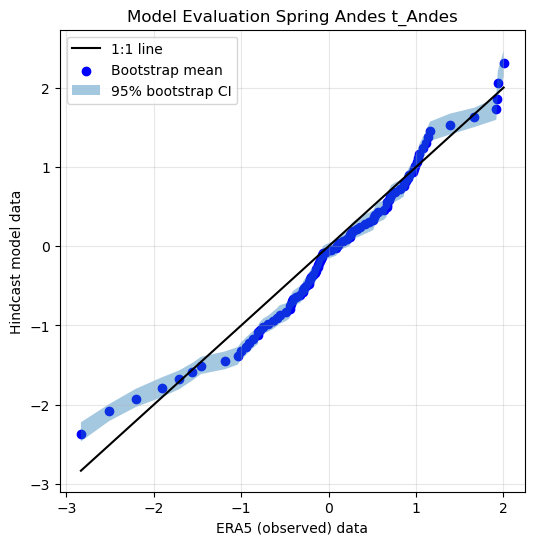

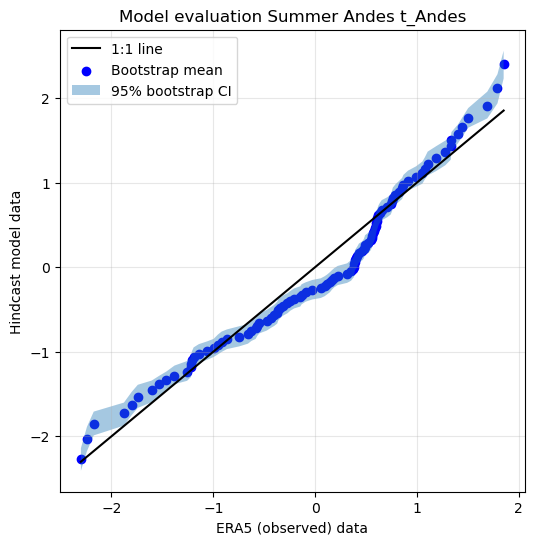

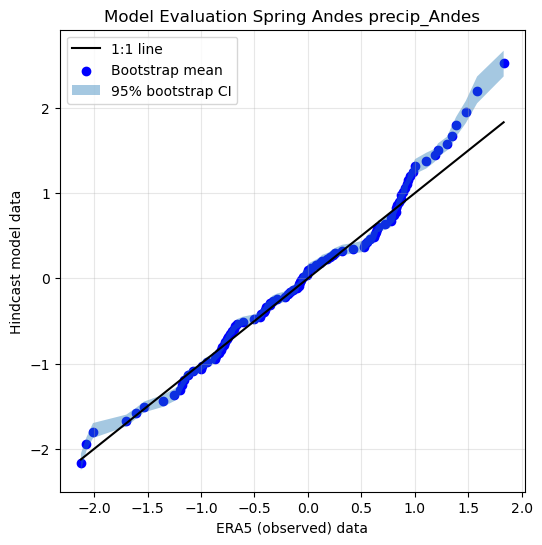

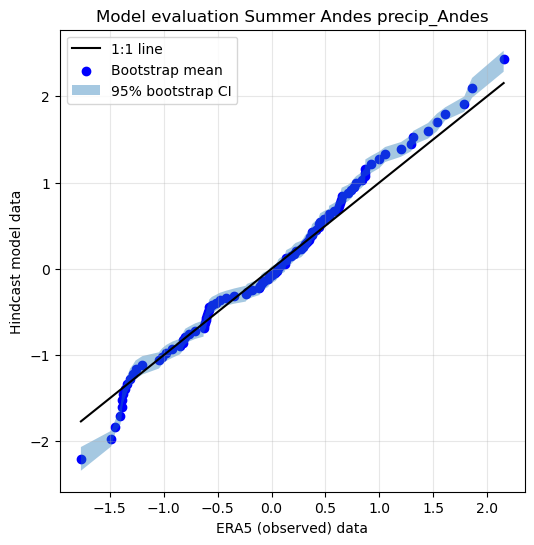

In [11]:
folder='Model_eval_plots/'
mapping = {
    list(ds_Andes_DJF.data_vars)[0]: "t_Andes",
    list(ds_Andes_DJF.data_vars)[1]: "precip_Andes"  
}
for var, era_var in mapping.items():
    a=bootstrap_chain(ds_Andes_SON, 1000, var=var)
    boot_perc_Andes_SON, era5_perc_Andes_SON, fig_Andes=model_eval_plot(a, era5_array=era_SON_Andes_array[era_var],
                                                input_title=f'Model Evaluation Spring Andes {era_var}')
    fig_Andes.savefig(folder+f'model_eval_Andes_spring_{era_var}.jpg', dpi=300)
    b=bootstrap_chain(ds_Andes_DJF, 1000, var=var)
    boot_perc_Andes_DJF, era5_perc_Andes_DJF, fig_Andes_DJF=model_eval_plot(b,
                                                             era_DJF_Andes_array[era_var],
                                                             input_title=f'Model evaluation Summer Andes {era_var}')
    fig_Andes_DJF.savefig(folder+f'model_eval_Andes_summer_{era_var}.jpg', dpi=300)

Separate the different lead times from each other

In [12]:
np.unique(ds_Andes_SON.init_month.values)

array([6, 7, 8, 9])

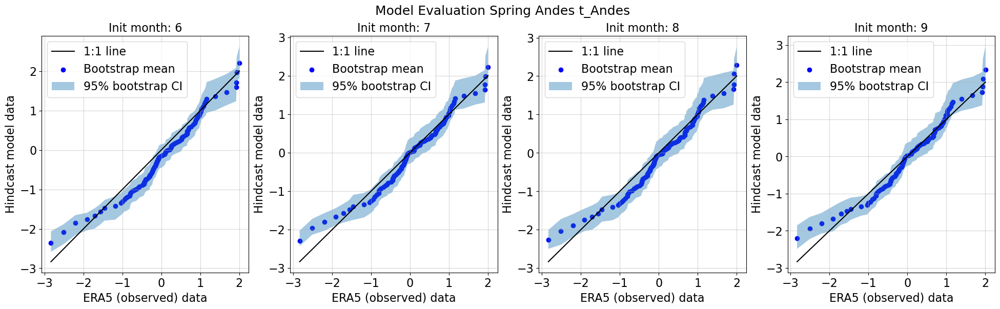

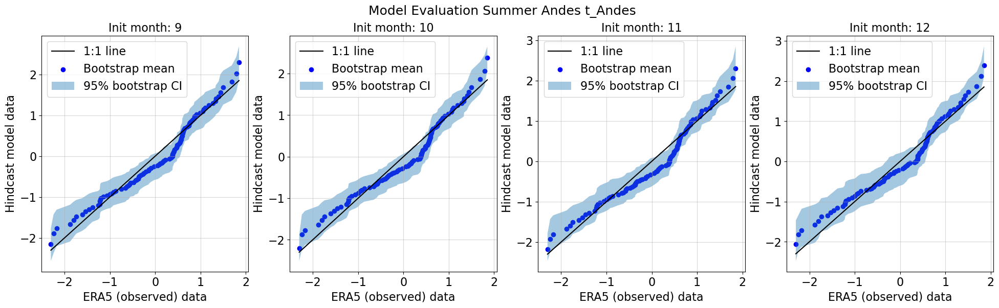

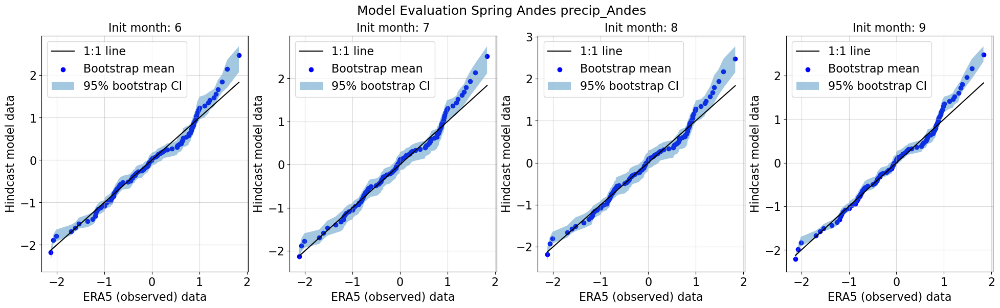

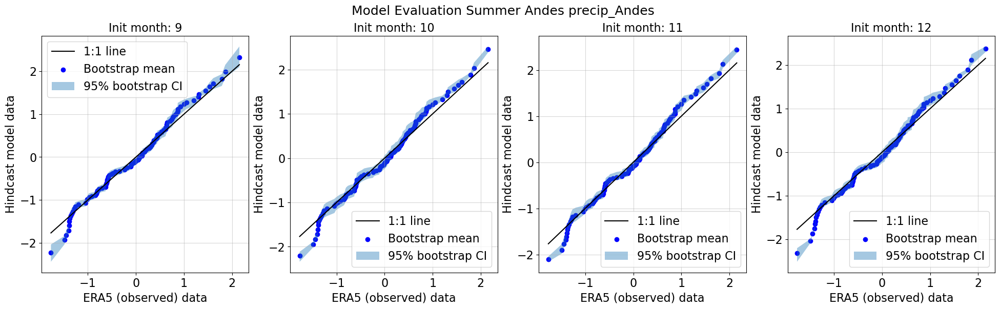

In [13]:
mapping = {
    list(ds_Andes_DJF.data_vars)[0]: "t_Andes",
    list(ds_Andes_DJF.data_vars)[1]: "precip_Andes"  
}
months_list_SON=list(np.unique(ds_Andes_SON.init_month.values))
months_list_DJF=list(np.unique(ds_Andes_DJF.init_month.values))

for var, era_var in mapping.items():
    a=bootstrap_chain(ds_Andes_SON, 1000, var=var, sep_lead=True)
    #print(np.shape(a))
    b=bootstrap_chain(ds_Andes_DJF, 1000, var=var, sep_lead=True)
    boot_perc_Andes_SON, era5_perc_Andes_SON, fig_Andes=model_eval_plot(a, era5_array=era_SON_Andes_array[era_var],
                                                    input_title=f'Model Evaluation Spring Andes {era_var}',
                                                    ds_init=ds_Andes_SON[var])
    boot_perc_Andes_DJF, era5_perc_Andes_DJF, fig_Andes_DJF=model_eval_plot(b, era5_array=era_DJF_Andes_array[era_var],
                                                        input_title=f'Model Evaluation Summer Andes {era_var}',
                                                        ds_init=ds_Andes_DJF[var])
    fig_Andes.savefig(folder+f'model_eval_Andes_spring_{era_var}_all_init.jpg', dpi=300)
    fig_Andes_DJF.savefig(folder+f'model_eval_Andes_summer_{era_var}_all_init.jpg', dpi=300)

    

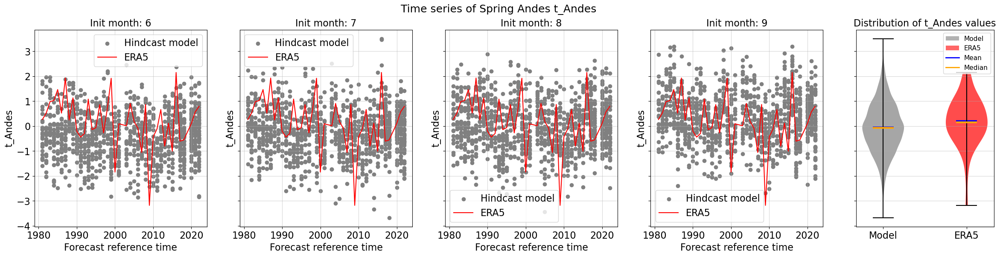

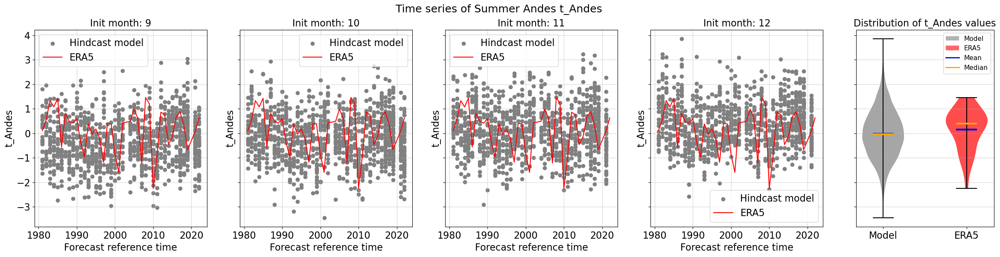

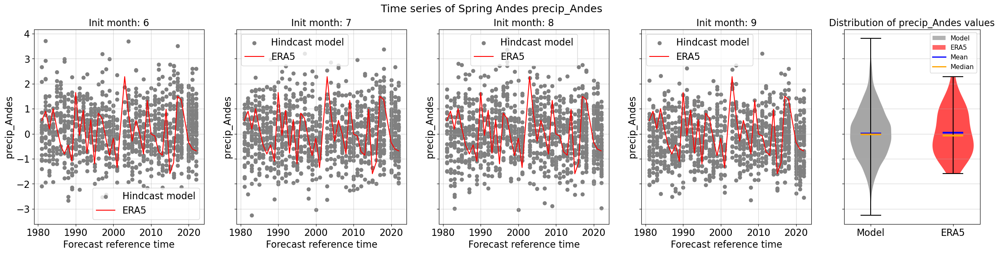

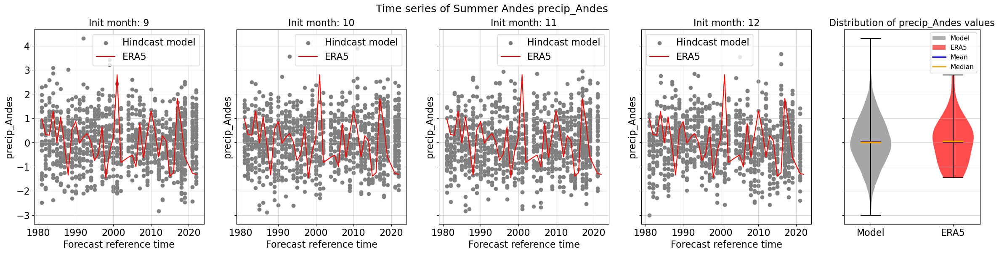

In [14]:
##timeseries of andes t2m and precip for all init months
for var, era_var in mapping.items():
    fig_ts_Andes_SON=time_series_plot(ds_Andes_SON[var], era_var=era_var, era5_array=era_SON_Andes_array,
                                      input_title=f'Time series of Spring Andes {era_var}')
    fig_ts_Andes_SON.savefig(folder+f'model_ts_Andes_spring_{era_var}.jpg', dpi=300)

    fig_ts_Andes_DJF=time_series_plot(ds_Andes_DJF[var], era_var=era_var, era5_array=era_DJF_Andes_array,
                                          input_title=f'Time series of Summer Andes {era_var}')
    fig_ts_Andes_DJF.savefig(folder+f'model_ts_Andes_summer_{era_var}.jpg', dpi=300)

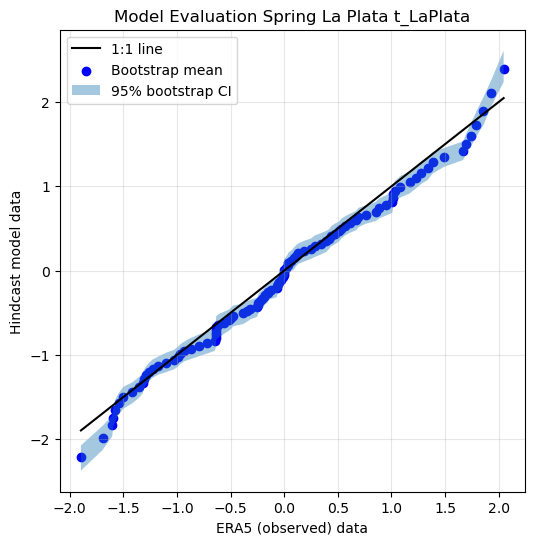

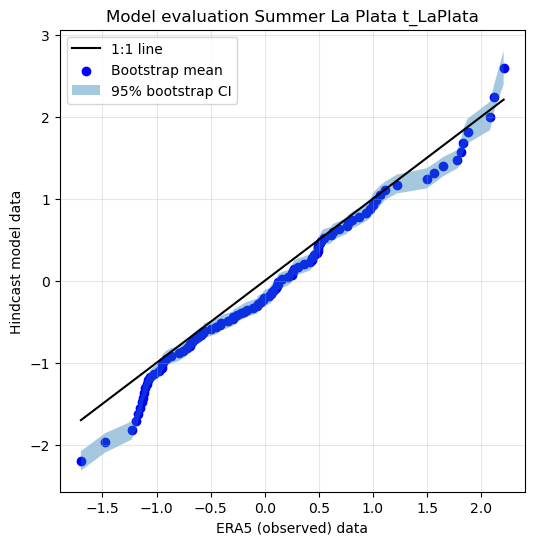

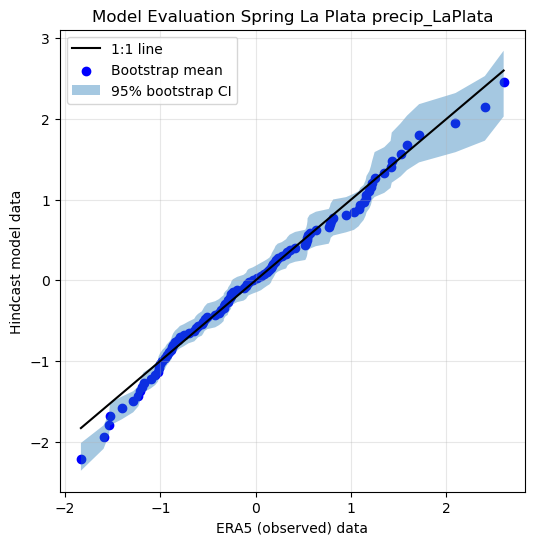

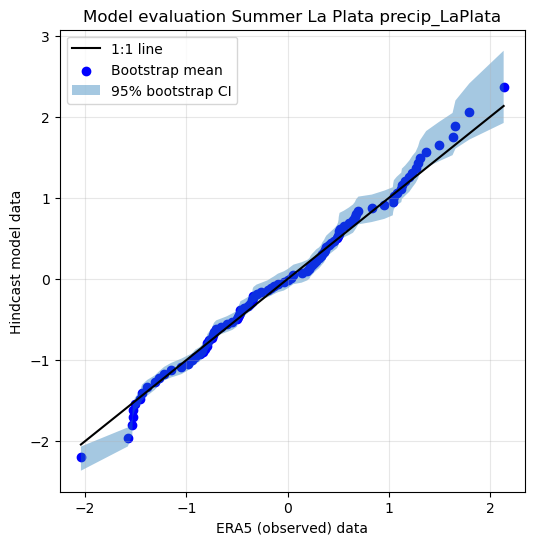

In [15]:
ds_LP_SON = ds_LP_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_LP_DJF = ds_LP_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)
folder='Model_eval_plots/'
mapping2 = {
    list(ds_LP_DJF.data_vars)[0]: "t_LaPlata",
    list(ds_LP_DJF.data_vars)[1]: "precip_LaPlata"  
}
for var, era_var in mapping2.items():
    a=bootstrap_chain(ds_LP_SON, 1000, var=var)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                input_title=f'Model Evaluation Spring La Plata {era_var}')
    fig_LP.savefig(folder+f'model_eval_LP_spring_{era_var}.jpg', dpi=300)
    b=bootstrap_chain(ds_LP_DJF, 1000, var=var)
    boot_perc_LP_DJF, era5_perc_LP_DJF, fig_LP_DJF=model_eval_plot(b,
                                                             era_DJF_LaPlata_array[era_var],
                                                             input_title=f'Model evaluation Summer La Plata {era_var}')
    fig_LP_DJF.savefig(folder+f'model_eval_LP_summer_{era_var}.jpg', dpi=300)

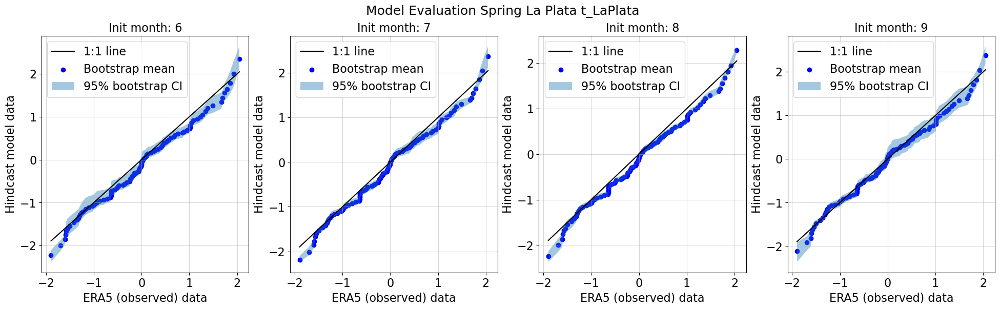

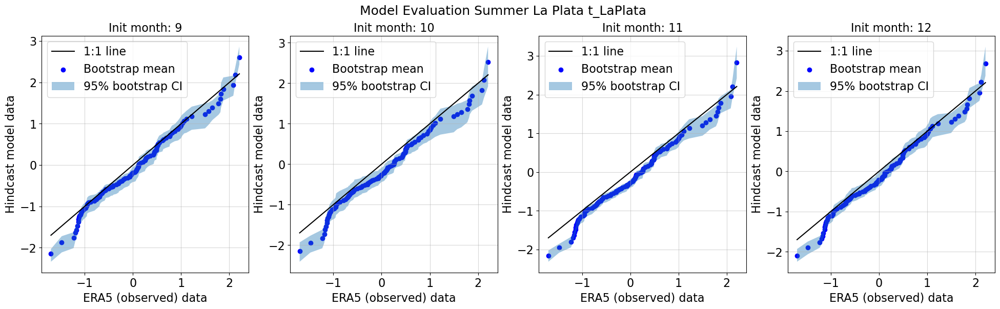

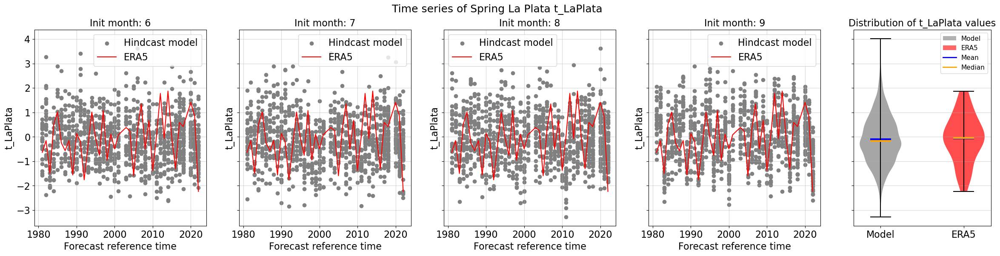

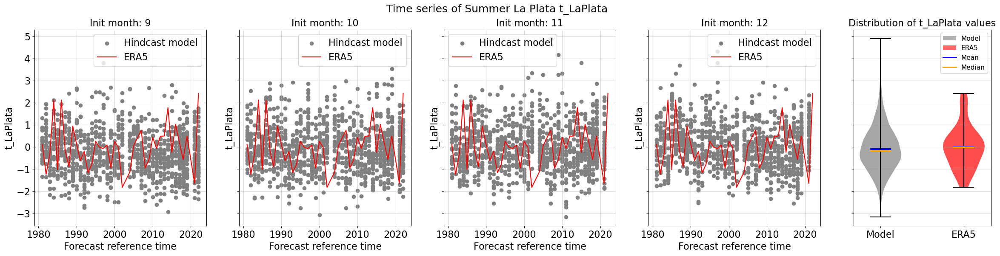

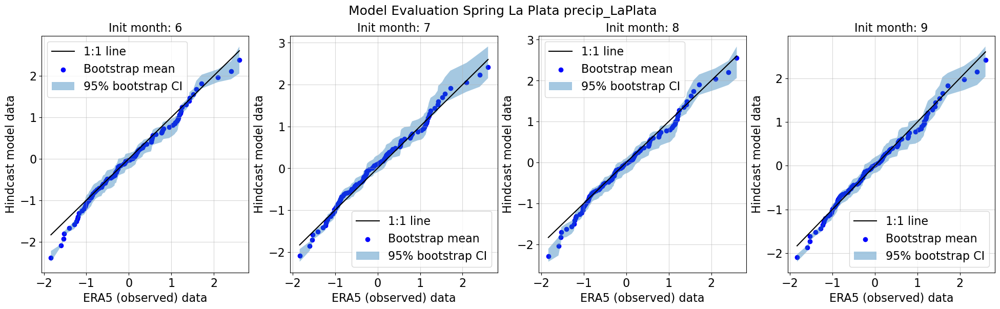

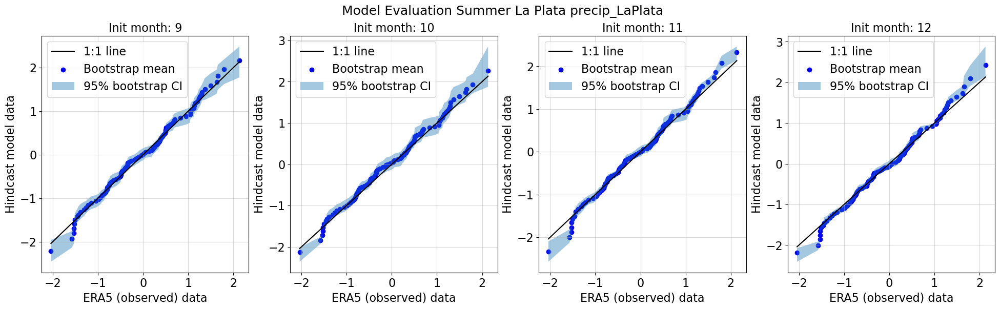

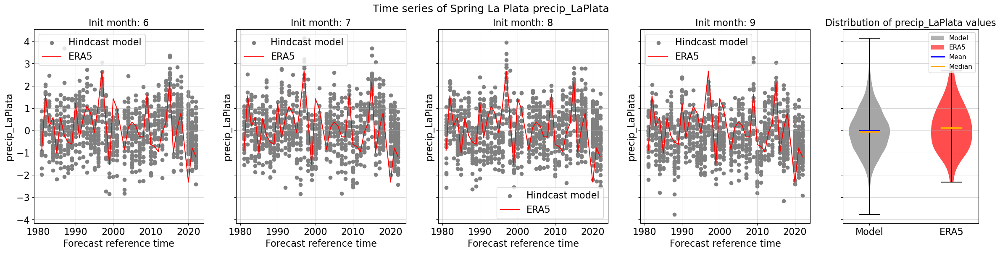

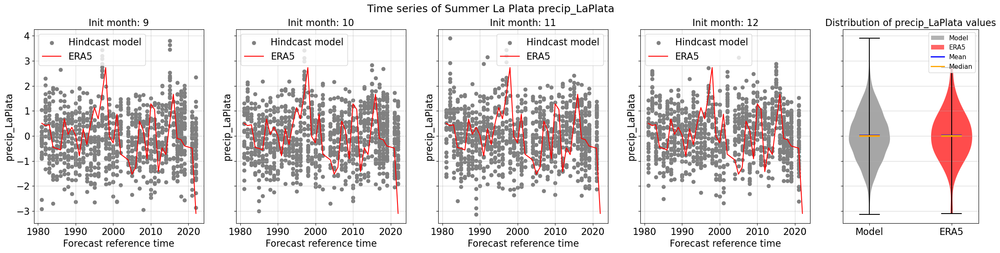

In [16]:

folder='Model_eval_plots/'
mapping = {
    list(ds_LP_DJF.data_vars)[0]: "t_LaPlata",
    list(ds_LP_DJF.data_vars)[1]: "precip_LaPlata"  
}
months_list_SON=list(np.unique(ds_LP_SON.init_month.values))
months_list_DJF=list(np.unique(ds_LP_DJF.init_month.values))

for var, era_var in mapping.items():
    a=bootstrap_chain(ds_LP_SON, 1000, var=var, sep_lead=True)
    #print(np.shape(a))
    b=bootstrap_chain(ds_LP_DJF, 1000, var=var, sep_lead=True)

    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                        input_title=f'Model Evaluation Spring La Plata {era_var}',
                                                        ds_init=ds_LP_SON[var])
    boot_perc_LP_DJF, era5_perc_LP_DJF, fig_LP_DJF=model_eval_plot(b, era5_array=era_DJF_LaPlata_array[era_var],
                                                            input_title=f'Model Evaluation Summer La Plata {era_var}',
                                                            ds_init=ds_LP_DJF[var])
    
    fig_LP.savefig(folder+f'model_eval_LaPlata_spring_{era_var}_all_init.jpg', dpi=300)
    fig_LP_DJF.savefig(folder+f'model_eval_LaPlata_summer_{era_var}_all_init.jpg', dpi=300)

    ##timeseries of LP Spring t2m and precip for all init months
    fig_ts_LP_SON=time_series_plot(ds_LP_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                      input_title=f'Time series of Spring La Plata {era_var}')
    fig_ts_LP_SON.savefig(folder+f'model_ts_LP_spring_{era_var}.jpg', dpi=300)

    ##timeseries of LP summer t2m and precip for all init months
    fig_ts_LP_DJF=time_series_plot(ds_LP_DJF[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                          input_title=f'Time series of Summer La Plata {era_var}')
    fig_ts_LP_DJF.savefig(folder+f'model_ts_LP_summer_{era_var}.jpg', dpi=300)
        

# Evaluate computed indices

In [17]:
#load indices data
ds_ocean_SON=xr.open_dataset(path+'ENSO_IOD_SON.nc')
ds_ocean_DJF=xr.open_dataset(path+'ENSO_IOB_DJF.nc')

ds_ocean_SON=drop_duplicates(ds_ocean_SON)
ds_ocean_DJF=drop_duplicates(ds_ocean_DJF)

ds_ocean_SON=exclude_years(ds_ocean_SON, years_list=[2002,2019])
ds_ocean_DJF=exclude_years(ds_ocean_DJF, years_list=[2003,2020])



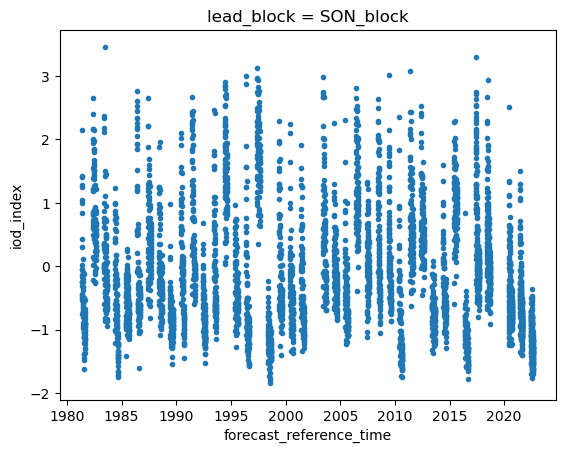

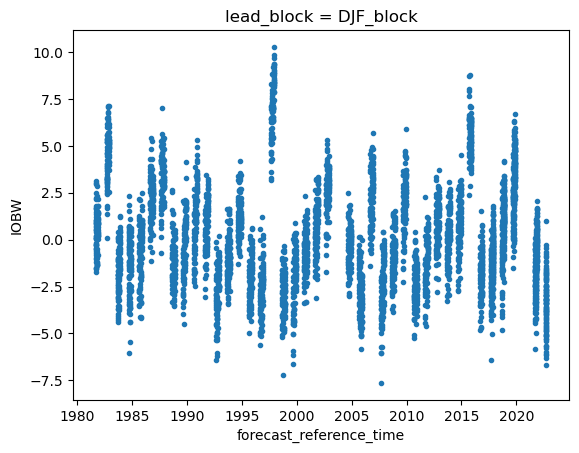

In [18]:
ds_ocean_SON['iod_index'].plot(x='forecast_reference_time', marker='.', linestyle='none')
list(ds_ocean_SON.data_vars)[0]
plt.show()
ds_ocean_DJF['IOBW'].plot(x='forecast_reference_time', marker='.', linestyle='none')

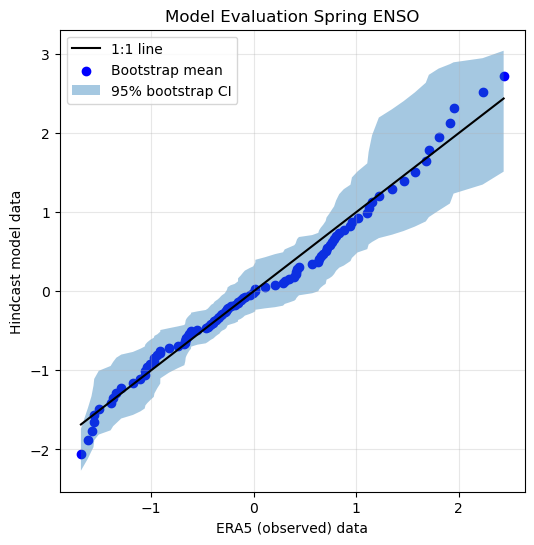

-2.699493983451724 3.143562231628764


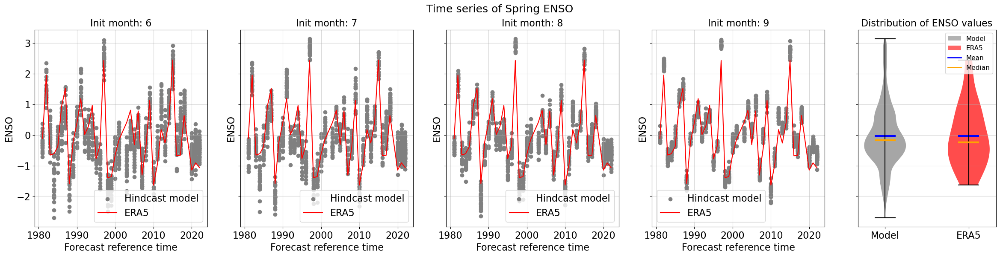

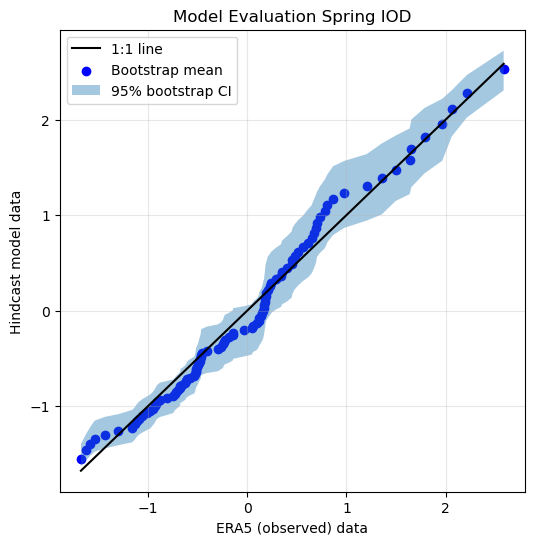

-1.8389270197778818 3.457282804493291


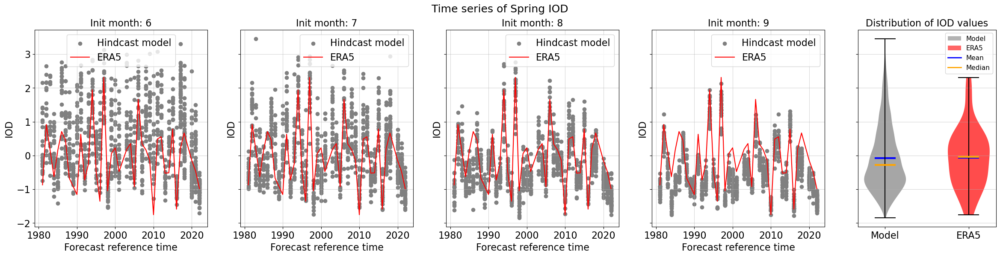

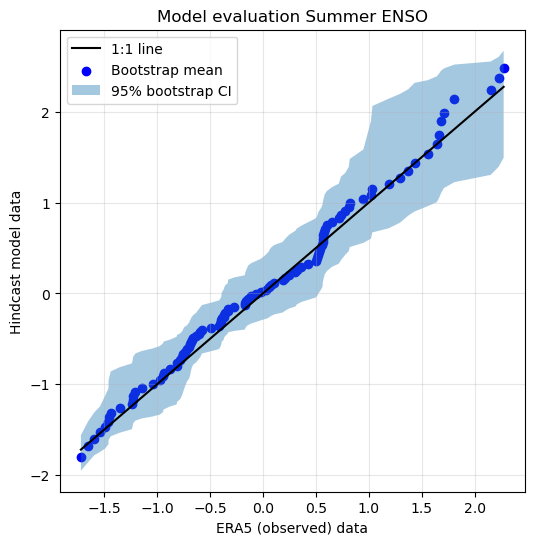

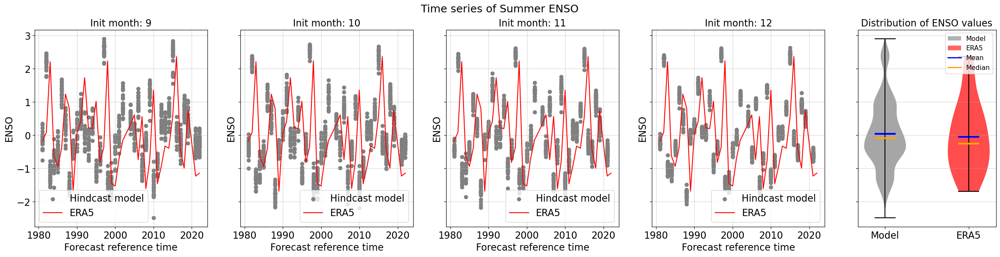

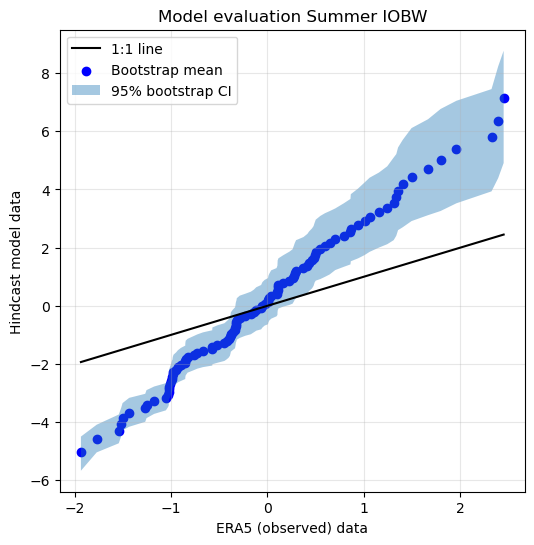

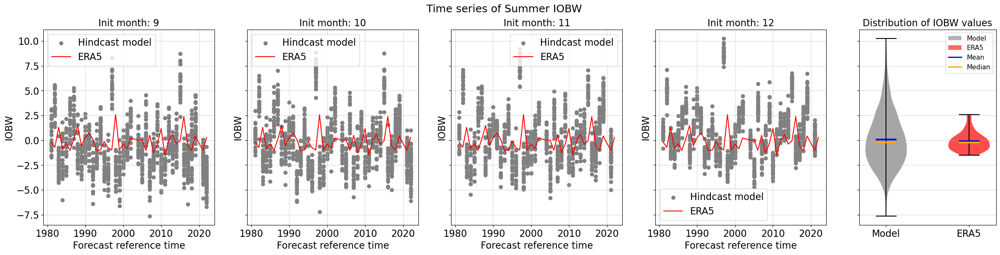

In [19]:
ds_ocean_SON = ds_ocean_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_ocean_DJF = ds_ocean_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)
folder='Model_eval_plots/'
mapping_oc_SON = {
    #list(ds_ocean_SON.data_vars)[1]: "ENSO",
    #list(ds_ocean_SON.data_vars)[0]: "IOD"  
    'nino34':'ENSO',
    'iod_index':'IOD'
}
mapping_oc_DJF = {
    #list(ds_ocean_DJF.data_vars)[1]: "ENSO",
    #list(ds_ocean_DJF.data_vars)[0]: "IOBW"  
    'nino34':'ENSO',
    'IOBW':'IOBW'
}
for var, era_var in mapping_oc_SON.items():
    a=bootstrap_chain(ds_ocean_SON, 1000, var=var)
    boot_perc_oc_SON, era5_perc_oc_SON, fig_oc=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                input_title=f'Model Evaluation Spring {era_var}')
    fig_oc.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

    ##timeseries of ENSO & IOD Spring for all init months
    print(np.nanmin(ds_ocean_SON[var]), np.nanmax(ds_ocean_SON[var]))
    fig_ts_oc_SON=time_series_plot(ds_ocean_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                          input_title=f'Time series of Spring {era_var}')
    fig_ts_oc_SON.savefig(folder+f'model_ts_spring_{era_var}.jpg', dpi=300)

for var, era_var in mapping_oc_DJF.items():
    b=bootstrap_chain(ds_ocean_DJF, 1000, var=var)
    boot_perc_oc_DJF, era5_perc_oc_DJF, fig_oc_DJF=model_eval_plot(b,
                                                             era_DJF_LaPlata_array[era_var],
                                                             input_title=f'Model evaluation Summer {era_var}')
    fig_oc_DJF.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)

    ##timeseries of LP Spring t2m and precip for all init months
    fig_ts_oc_DJF=time_series_plot(ds_ocean_DJF[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                          input_title=f'Time series of Summer {era_var}')
    fig_ts_oc_DJF.savefig(folder+f'model_ts_summer_{era_var}.jpg', dpi=300)

In [20]:
list(ds_ocean_SON.data_vars)
#0 is iod_index/IOB, 1 is nino34

['iod_index', 'nino34']

nino34 ENSO


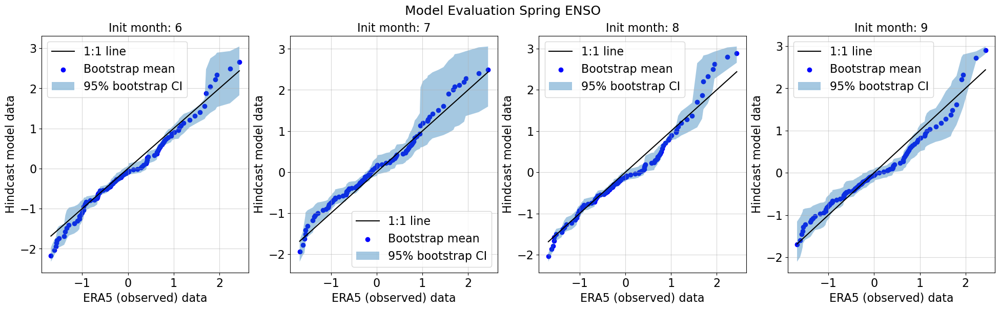

-2.1072246735140707 2.993248330183209
iod_index IOD


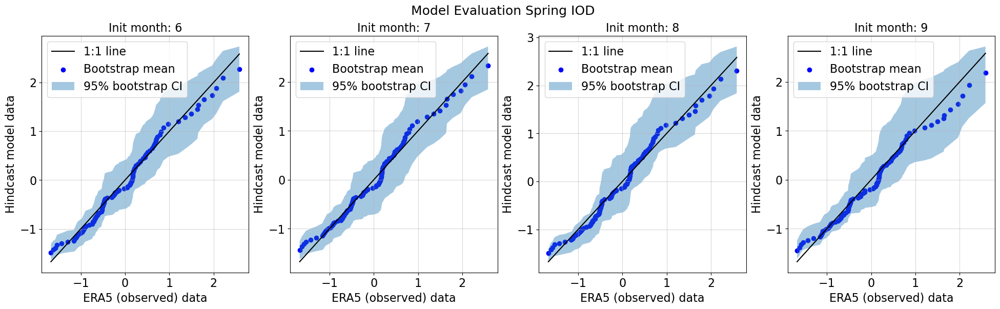

-1.6192322376886872 2.744420387274527
nino34 ENSO


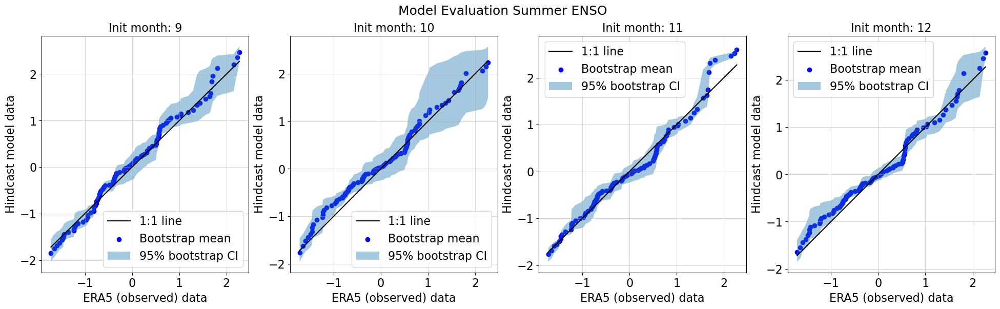

IOBW IOBW


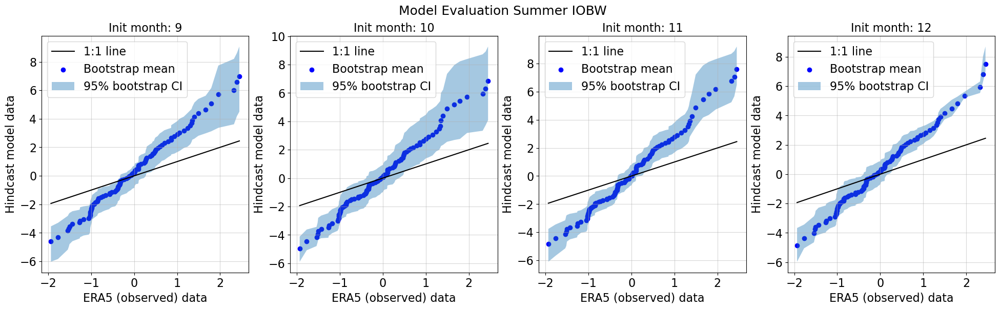

In [21]:
#separate init months
folder='Model_eval_plots/'
#mapping = {
#    list(ds_ocean_SON.data_vars)[1]: "ENSO",
#    list(ds_ocean_SON.data_vars)[0]: "IOD" 
#}


months_list_SON=list(np.unique(ds_ocean_SON.init_month.values))
months_list_DJF=list(np.unique(ds_ocean_DJF.init_month.values))

for var, era_var in mapping_oc_SON.items():
    print(var, era_var)
    a=bootstrap_chain(ds_ocean_SON, 1000, var=var, sep_lead=True)
    #print(np.shape(a))

    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                            input_title=f'Model Evaluation Spring {era_var}',
                                                            ds_init=ds_ocean_SON[var])
    print(np.min(boot_perc_LP_SON), np.max(boot_perc_LP_SON))
        
    fig_LP.savefig(folder+f'model_eval_spring_{era_var}_all_init.jpg', dpi=300)
        

for var, era_var in mapping_oc_DJF.items():
        print(var, era_var)
        b=bootstrap_chain(ds_ocean_DJF, 1000, var=var, sep_lead=True)
        boot_perc_LP_DJF, era5_perc_LP_DJF, fig_LP_DJF=model_eval_plot(b, era5_array=era_DJF_LaPlata_array[era_var],
                                                                        input_title=f'Model Evaluation Summer {era_var}',
                                                                        ds_init=ds_ocean_DJF[var])
        fig_LP_DJF.savefig(folder+f'model_eval_summer_{era_var}_all_init.jpg', dpi=300)
        

Vortex evaluation

In [22]:
ds_strato_SON = ds_strato_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

Text(0.5, 1.0, 'SPV index time series')

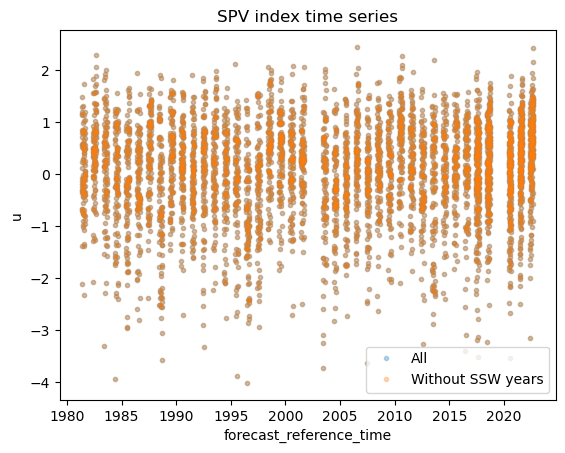

In [23]:
#try excluding the SSW years -->especially weak polar vortex
ssw_years=[2002,2019]
mask_ssw=ds_strato_SON.forecast_reference_time.dt.year.isin(ssw_years)
ds_strato_SON_fix=ds_strato_SON.where(~mask_ssw, drop=True)

ds_strato_SON['u'].plot(marker='.', linestyle='none', x='forecast_reference_time', alpha=0.3, label='All')
ds_strato_SON_fix['u'].plot(marker='.', linestyle='none', x='forecast_reference_time', alpha=.3, label='Without SSW years')
plt.legend()
plt.title('SPV index time series')

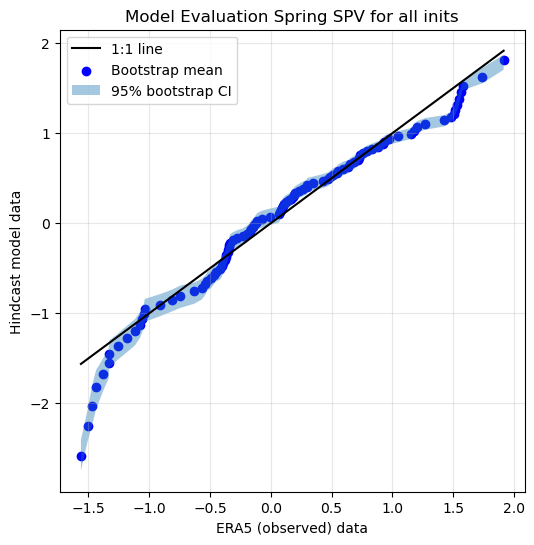

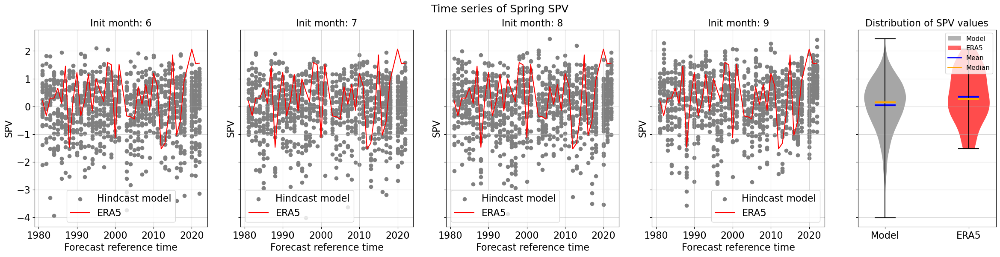

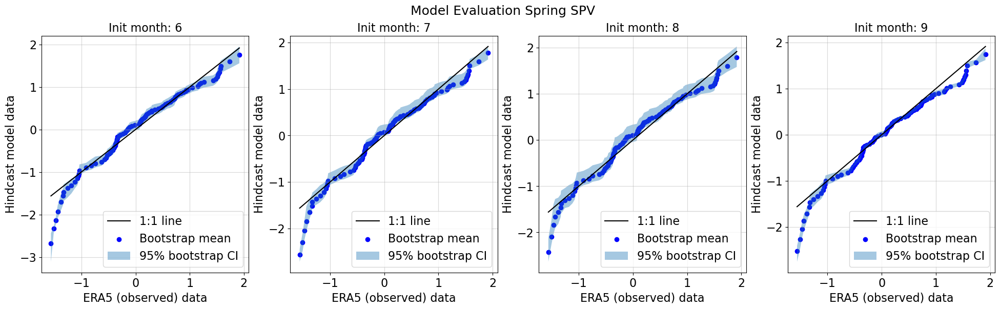

In [24]:
#separate init months
folder='Model_eval_plots/'
mapping = {
    list(ds_strato_SON.data_vars)[0]: "SPV"}

months_list_SON=list(np.unique(ds_strato_SON.init_month.values))
for var, era_var in mapping.items():
    a=bootstrap_chain(ds_strato_SON, 1000, var=var)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 1000, var=var)

    boot_perc_SPV_SON, era5_perc_SPV_SON, fig_whole=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Spring {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

    fig_ts_SPV_SON=time_series_plot(ds_strato_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                          input_title=f'Time series of Spring {era_var}')
    fig_ts_SPV_SON.savefig(folder+f'model_ts_spring_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(ds_strato_SON, 1000, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Spring {era_var}',
                                                                ds_init=ds_strato_SON[var])
            
    fig_LP.savefig(folder+f'model_eval_spring_{era_var}_all_init.jpg', dpi=300)
    

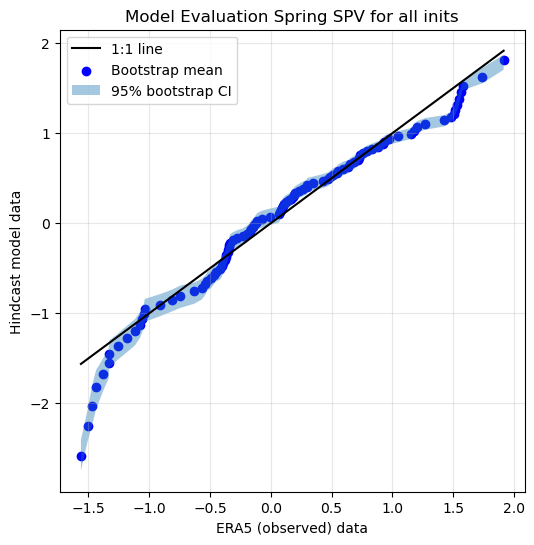

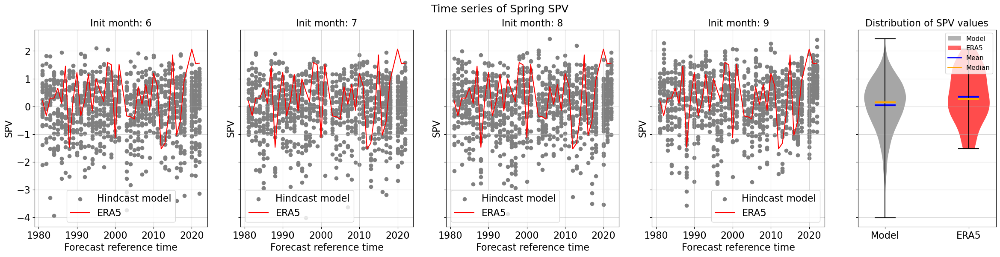

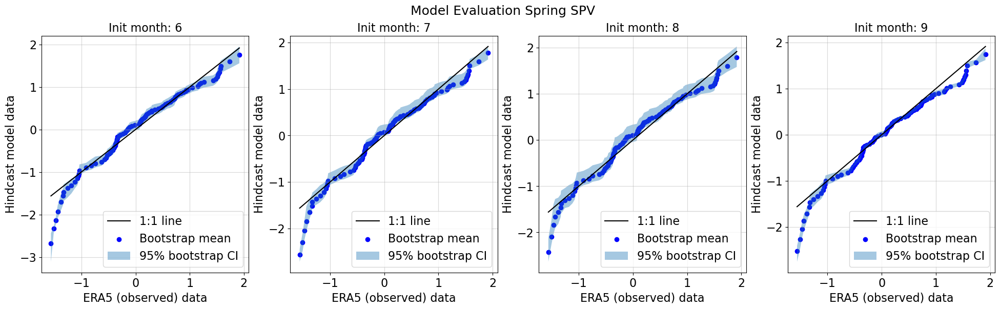

In [25]:
#separate init months
folder='Model_eval_plots/'
mapping = {
    list(ds_strato_SON_fix.data_vars)[0]: "SPV"}

months_list_SON=list(np.unique(ds_strato_SON_fix.init_month.values))
for var, era_var in mapping.items():
    a=bootstrap_chain(ds_strato_SON_fix, 1000, var=var)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 1000, var=var)

    boot_perc_SPV_SON, era5_perc_SPV_SON, fig_whole=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Spring {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

    fig_ts_SPV_SON=time_series_plot(ds_strato_SON_fix[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                          input_title=f'Time series of Spring {era_var}')
    #fig_ts_SPV_SON.savefig(folder+f'model_ts_spring_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(ds_strato_SON_fix, 1000, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Spring {era_var}',
                                                                ds_init=ds_strato_SON_fix[var])
            
    #fig_LP.savefig(folder+f'model_eval_spring_{era_var}_all_init.jpg', dpi=300)
    

VB index prep

In [4]:
def detrend_across_time(ds):
    """
    Remove a linear trend across time.

    Important:
    Your dimension is called 'sample', not 'time'.

    Each sample has a coordinate called 'forecast_reference_time'.
    We extract the year from that coordinate and regress each grid point
    against year.

    Because you have 51 ensemble members per year, the same year appears
    many times. That is okay: the trend is fitted across all samples.
    """

    # Extract year from forecast_reference_time
    years = xr.DataArray(
        ds["forecast_reference_time"].dt.year.values,
        dims="sample",
        coords={"sample": ds["sample"]},
        name="year"
    )

    # Center the year to make the regression numerically cleaner
    x = years - years.mean(dim="sample")

    # Output container
    detrended_vars = {}

    for var in ds.data_vars:

        y = ds[var]

        # Mean over sample
        y_mean = y.mean(dim="sample")

        # Linear regression slope:
        # slope = cov(x, y) / var(x)
        slope = ((x * (y - y_mean)).mean(dim="sample")) / ((x ** 2).mean(dim="sample"))

        # Fitted linear trend
        fit = y_mean + slope * x

        # Remove fitted trend
        detrended_vars[var] = y - fit

    out = xr.Dataset(detrended_vars, coords=ds.coords)

    return out


def spatial_average(ds):
    """
    Latitude-weighted spatial average.

    Output:
        one value per sample
    """

    weights = np.cos(np.deg2rad(ds["latitude"]))

    out = ds.weighted(weights).mean(dim=["latitude", "longitude"])

    return out

def standardize(ds):
    """
    Standardize each variable across samples.

    z = value / std

    The mean should already be near zero after anomaly + detrending.
    If you want strict z-score, use:
        (ds - ds.mean("sample")) / ds.std("sample")
    """

    return ds / ds.std(dim="sample")

In [6]:

VB_Aug=pd.read_csv(path+'SEAS5_VortexBreakdown_DOY_Aug.csv')
VB_Sep=pd.read_csv(path+'SEAS5_VortexBreakdown_DOY_Sep.csv')
VB_Oct=pd.read_csv(path+'SEAS5_VortexBreakdown_DOY_Oct.csv')
#display(VB_Sep['forecast_reference_time'])
#display(VB_Aug['forecast_reference_time'])
display(VB_Oct['VB_DOY'].where(VB_Oct['VB_DOY']<100).dropna())
VB_Aug['init_month']=8
VB_Sep['init_month']=9
VB_Oct['init_month']=10
#display(era_DJF_Andes_array['VB'])
VB_all=pd.concat([VB_Aug, VB_Sep, VB_Oct], axis=0)
VB_all["forecast_reference_time"] = pd.to_datetime(
    VB_all["forecast_reference_time"]
)

#VB_all["year"] = VB_all["forecast_reference_time"].dt.year
#VB_all['year']=VB_all['forecast_reference_time'].str.slice(0,4).astype(int)
display(VB_all)

#set multi index sample
VB_DOY_array = (
    VB_all
    .set_index(["init_month", "number", 'forecast_reference_time'])
    .to_xarray()
)
VB_DOY_array=VB_DOY_array.stack(sample=["init_month", "forecast_reference_time", "number"]).drop_vars(['latitude'])

display(VB_DOY_array)

VB_DOY_era5=xr.open_dataset('../ERA5_dyn_data_ready/VB_DOY_absolute_era5.nc')
VB_DOY_era5=xr.where(VB_DOY_era5['dayofyear']<100, VB_DOY_era5['dayofyear']+365, VB_DOY_era5['dayofyear'])
display(VB_DOY_era5)

Series([], Name: VB_DOY, dtype: float64)

,number,forecast_reference_time,latitude,VB_DOY,init_month
0,0,1981-08-01,-60,336.0,8
1,0,1982-08-01,-60,337.0,8
2,0,1983-08-01,-60,316.0,8
3,0,1984-08-01,-60,327.0,8
4,0,1985-08-01,-60,322.0,8
...,...,...,...,...,...
2137,50,2018-10-01,-60,347.0,10
2138,50,2019-10-01,-60,350.0,10
2139,50,2020-10-01,-60,341.0,10
2140,50,2021-10-01,-60,336.0,10


<xarray.Dataset> Size: 771kB
Dimensions:                  (sample: 19278)
Coordinates:
  * sample                   (sample) object 154kB MultiIndex
  * init_month               (sample) int64 154kB 8 8 8 8 8 8 ... 10 10 10 10 10
  * forecast_reference_time  (sample) datetime64[ns] 154kB 1981-08-01 ... 202...
  * number                   (sample) int64 154kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    VB_DOY                   (sample) float64 154kB 336.0 349.0 ... 368.0 343.0

<xarray.DataArray 'dayofyear' (year: 77)> Size: 616B
array([368., 319., 316., 341., 326., 333., 332., 325., 310., 331., 342.,
       327., 344., 319., 336., 314., 336., 326., 325., 315., 337., 333.,
       326., 329., 324., 320., 326., 321., 324., 318., 324., 327., 337.,
       333., 339., 336., 345., 339., 345., 323., 341., 348., 322., 342.,
       340., 328., 352., 350., 336., 356., 367., 331., 359., 337., 332.,
       332., 341., 350., 356., 359., 336., 355., 351., 324., 331., 346.,
       347., 324., 344., 336., 313., 362., 367., 366., 363.,  nan,  nan])
Coordinates:
  * year     (year) int64 616B 1950 1951 1952 1953 1954 ... 2023 2024 2025 2026

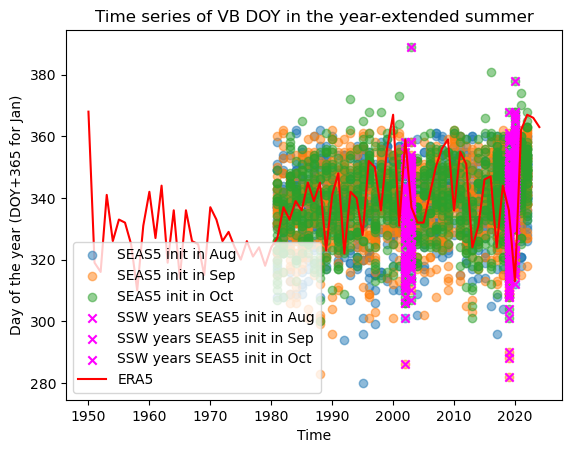

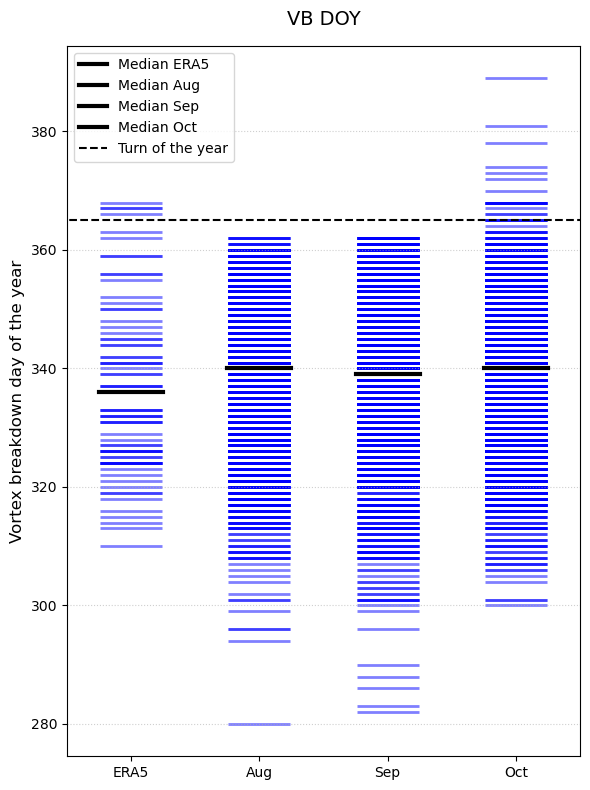

In [7]:
#do plots with absolute values of era5 and model data

#1. time series
plt.scatter(pd.to_datetime(VB_Aug.forecast_reference_time).dt.year, VB_Aug['VB_DOY'], alpha=.5, label='SEAS5 init in Aug')
plt.scatter(pd.to_datetime(VB_Sep.forecast_reference_time).dt.year, VB_Sep['VB_DOY'], alpha=0.5, label='SEAS5 init in Sep')
plt.scatter(pd.to_datetime(VB_Oct.forecast_reference_time).dt.year, VB_Oct['VB_DOY'], alpha=0.5, label='SEAS5 init in Oct')
#add SSW as special marker
mask_ssw_Aug=pd.to_datetime(VB_Aug.forecast_reference_time).dt.year.isin([2002,2003,2019,2020])
mask_ssw_Sep=pd.to_datetime(VB_Sep.forecast_reference_time).dt.year.isin([2002,2003,2019,2020])
mask_ssw_Oct=pd.to_datetime(VB_Oct.forecast_reference_time).dt.year.isin([2002,2003,2019,2020])

VB_Aug_fix=VB_Aug.where(mask_ssw_Aug)
VB_Sep_fix=VB_Sep.where(mask_ssw_Sep)
VB_Oct_fix=VB_Oct.where(mask_ssw_Oct)

VB_Aug_no_SSW=VB_Aug.where(~mask_ssw_Aug)
VB_Sep_no_SSW=VB_Sep.where(~mask_ssw_Sep)
VB_Oct_no_SSW=VB_Oct.where(~mask_ssw_Oct)

plt.scatter(pd.to_datetime(VB_Aug_fix.forecast_reference_time).dt.year, VB_Aug_fix['VB_DOY'], 
            label='SSW years SEAS5 init in Aug', marker='x', color='magenta') 
plt.scatter(pd.to_datetime(VB_Sep_fix.forecast_reference_time).dt.year, VB_Sep_fix['VB_DOY'], 
            label='SSW years SEAS5 init in Sep', marker='x', color='magenta')
plt.scatter(pd.to_datetime(VB_Oct_fix.forecast_reference_time).dt.year, VB_Oct_fix['VB_DOY'], 
            label='SSW years SEAS5 init in Oct', marker='x', color='magenta')

plt.plot(VB_DOY_era5['year'], VB_DOY_era5, color='red', label='ERA5')
plt.legend()
plt.title('Time series of VB DOY in the year-extended summer')
plt.xlabel('Time')
plt.ylabel('Day of the year (DOY+365 for Jan)')
plt.show()

#2. box plot thingy?

monate_data = [VB_DOY_era5, VB_Aug['VB_DOY'], VB_Sep['VB_DOY'], VB_Oct['VB_DOY']]
monate_namen = ['ERA5', 'Aug', 'Sep', 'Oct']
x_positionen = [1, 2, 3, 4] 

fig, ax = plt.subplots(figsize=(6, 8))


for i, (x_pos, daten) in enumerate(zip(x_positionen, monate_data)):
    
    x_werte = np.full_like(daten, x_pos)
    
    # wide, horizontal stripes, just as in reference plot
    # s= width of stripes, linewidths= thickness of stripes
    ax.scatter(x_werte, daten, marker='_', s=2000, linewidths=2, color='blue', alpha=0.5)
    
    median_y = np.nanmedian(daten)
    ax.plot([x_pos - 0.25, x_pos + 0.25], [median_y, median_y], color='black', linewidth=3, label=f'Median {monate_namen[i]}')
    

ax.set_xticks(x_positionen)
ax.set_xticklabels(monate_namen)
ax.hlines(y=365, xmin=min(x_positionen)-1., xmax=max(x_positionen)+1., linestyle='--', 
          color='black', label='Turn of the year')
ax.set_xlim(0.5, 4.5) 
ax.set_ylabel('Vortex breakdown day of the year', fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.6) 

plt.title('VB DOY', fontsize=14, pad=15)
plt.legend()
plt.tight_layout()
plt.show()



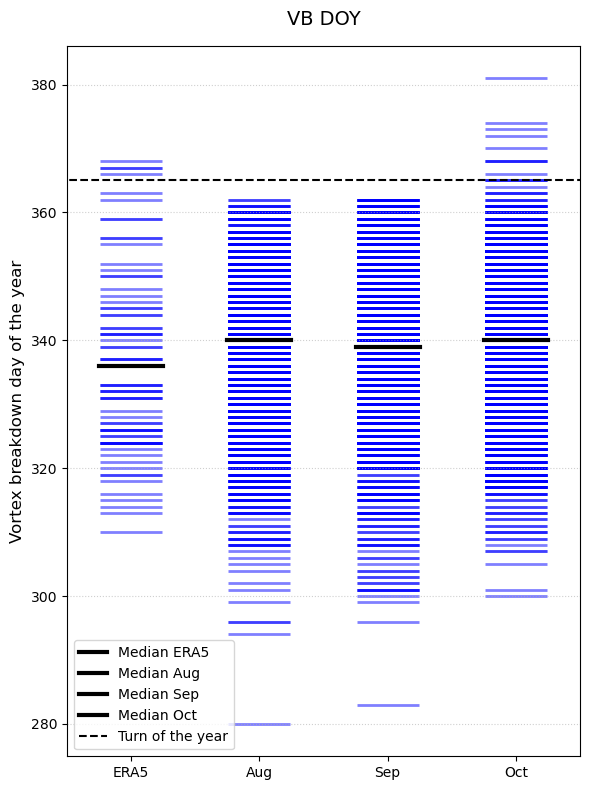

In [8]:
monate_data = [VB_DOY_era5, VB_Aug_no_SSW['VB_DOY'], VB_Sep_no_SSW['VB_DOY'], VB_Oct_no_SSW['VB_DOY']]
monate_namen = ['ERA5', 'Aug', 'Sep', 'Oct']
x_positionen = [1, 2, 3,4] 

fig, ax = plt.subplots(figsize=(6, 8))


for i, (x_pos, daten) in enumerate(zip(x_positionen, monate_data)):
    
    x_werte = np.full_like(daten, x_pos)
    
    # wide, horizontal stripes, just as in reference plot
    # s= width of stripes, linewidths= thickness of stripes
    ax.scatter(x_werte, daten, marker='_', s=2000, linewidths=2, color='blue', alpha=0.5)
    
    median_y = np.nanmedian(daten)
    ax.plot([x_pos - 0.25, x_pos + 0.25], [median_y, median_y], color='black', linewidth=3, label=f'Median {monate_namen[i]}')
    

ax.set_xticks(x_positionen)
ax.set_xticklabels(monate_namen)
ax.hlines(y=365, xmin=min(x_positionen)-1., xmax=max(x_positionen)+1., linestyle='--', 
          color='black', label='Turn of the year')
ax.set_xlim(0.5, 4.5) 
ax.set_ylabel('Vortex breakdown day of the year', fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.6) 

plt.title('VB DOY', fontsize=14, pad=15)
plt.legend()
plt.tight_layout()
plt.savefig('Model_eval_plots/VB_DOY_no_SSW.jpg', dpi=300)
plt.show()



<xarray.Dataset> Size: 771kB
Dimensions:                  (sample: 19278)
Coordinates:
  * sample                   (sample) object 154kB MultiIndex
  * init_month               (sample) int64 154kB 8 8 8 8 8 8 ... 10 10 10 10 10
  * forecast_reference_time  (sample) datetime64[ns] 154kB 1981-08-01 ... 202...
  * number                   (sample) int64 154kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    VB_DOY                   (sample) float64 154kB 0.1299 1.202 ... 0.01689

6426 6426


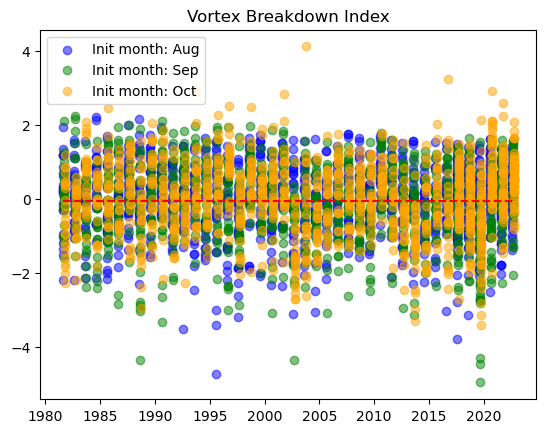

In [9]:
#compute preparation of VB date

#1. detrend
detr_VB= detrend_across_time(VB_DOY_array)
#2. standardize
VB_index=standardize(detr_VB)

VB_index['VB_DOY'].reset_index('sample').to_netcdf(path+'VB_DOY_combined.nc') #, encoding={"zlib": True, "complevel": 4})
display(VB_index)
#print(sum(~np.isnan(VB_index)))
VB_Aug_index=VB_index.sel(init_month=8)['VB_DOY']
VB_Sep_index=VB_index.sel(init_month=9)['VB_DOY']
VB_Oct_index=VB_index.sel(init_month=10)['VB_DOY']

print(len(VB_Aug_index), len(VB_Aug_index['forecast_reference_time']))
plt.scatter(VB_Aug_index.forecast_reference_time, VB_Aug_index, color='blue', label='Init month: Aug',alpha=.5)
plt.scatter(VB_Sep_index.forecast_reference_time, VB_Sep_index, color='green', label='Init month: Sep', alpha=0.5)
plt.scatter(VB_Oct_index.forecast_reference_time, VB_Oct_index, color='orange', label='Init month: Oct', alpha=0.5)
plt.hlines(VB_index['VB_DOY'].mean(), VB_index.forecast_reference_time.min(), VB_index.forecast_reference_time.max(), colors='r', linestyles='dashed')
plt.title('Vortex Breakdown Index')
plt.legend()
plt.show()

In [10]:
#separate init months
VB_index=drop_duplicates(VB_index)
folder='Model_eval_plots/'
mapping = {
    list(VB_index.data_vars)[0]: "VB"}

months_list_SON=list(np.unique(VB_index.init_month.values))
for var, era_var in mapping.items():
    a=bootstrap_chain(VB_index, 1000, var=var)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 1000, var=var)

    boot_perc_VB_SON, era5_perc_VB_SON, fig_whole=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Summer {era_var} for all inits')
    #fig_whole.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)

    fig_ts_VB_SON=time_series_plot(VB_index[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                          input_title=f'Time series of Summer {era_var}')
    fig_ts_VB_SON.savefig(folder+f'model_ts_summer_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(VB_index, 1000, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Summer {era_var}',
                                                                ds_init=VB_index[var])
            
    #fig_LP.savefig(folder+f'model_eval_summer_{era_var}_all_init.jpg', dpi=300)
    

NameError: name 'bootstrap_chain' is not defined

,number,forecast_reference_time,latitude,VB_DOY,init_month
0,0.0,1981-08-01,-60.0,336.0,8.0
1,0.0,1982-08-01,-60.0,337.0,8.0
2,0.0,1983-08-01,-60.0,316.0,8.0
3,0.0,1984-08-01,-60.0,327.0,8.0
4,0.0,1985-08-01,-60.0,322.0,8.0
...,...,...,...,...,...
2137,50.0,2018-10-01,-60.0,347.0,10.0
2138,NaN,NaT,NaN,NaN,NaN
2139,NaN,NaT,NaN,NaN,NaN
2140,50.0,2021-10-01,-60.0,336.0,10.0


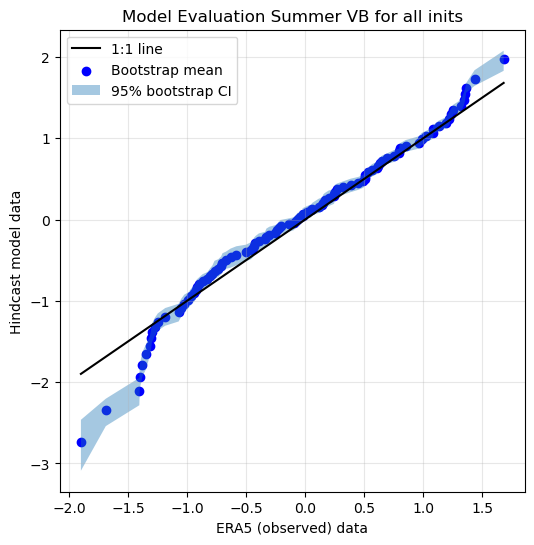

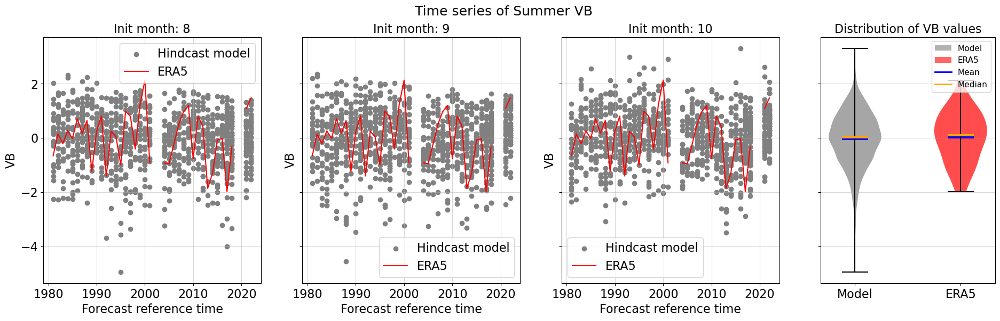

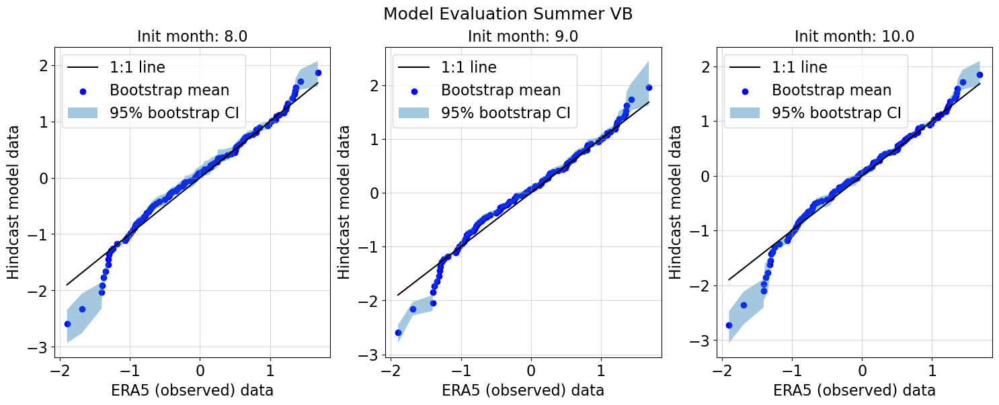

In [33]:
VB_all_no_SSW=pd.concat([VB_Aug_no_SSW, VB_Sep_no_SSW, VB_Oct_no_SSW], axis=0)
VB_all_no_SSW["forecast_reference_time"] = pd.to_datetime(
    VB_all_no_SSW["forecast_reference_time"]
)

display(VB_all_no_SSW)

#set multi index sample
VB_DOY_array_no_SSW = (
    VB_all_no_SSW.dropna()
    .set_index(["init_month", "number", 'forecast_reference_time'])
    .to_xarray()
)
VB_DOY_array_no_SSW=VB_DOY_array_no_SSW.stack(sample=["init_month", "forecast_reference_time", "number"]).drop_vars(['latitude'])
#1. detrend
detr_VB_no_SSW= detrend_across_time(VB_DOY_array_no_SSW)
#2. standardize
VB_index_no_SSW=standardize(detr_VB_no_SSW)


#separate init months

VB_index_no_SSW=drop_duplicates(VB_index_no_SSW)
folder='Model_eval_plots/'
mapping = {
    list(VB_index.data_vars)[0]: "VB"}

months_list_SON=list(np.unique(VB_index_no_SSW.init_month.values))
for var, era_var in mapping.items():
    a=bootstrap_chain(VB_index_no_SSW, 1000, var=var)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 1000, var=var)

    boot_perc_VB_SON, era5_perc_VB_SON, fig_whole=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Summer {era_var} for all inits')
    #fig_whole.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)

    fig_ts_VB_SON=time_series_plot(VB_index_no_SSW[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                          input_title=f'Time series of Summer {era_var}')
    #fig_ts_VB_SON.savefig(folder+f'model_ts_summer_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(VB_index, 1000, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Summer {era_var}',
                                                                ds_init=VB_index_no_SSW[var])
            
    #fig_LP.savefig(folder+f'model_eval_summer_{era_var}_all_init.jpg', dpi=300)
    

SAM evaluation

In [34]:
ds_SAM_SON=xr.open_dataset(path+'SAM_ready_SON.nc')
ds_SAM_DJF=xr.open_dataset(path+'SAM_ready_DJF.nc')

ds_SAM_SON=drop_duplicates(ds_SAM_SON)
ds_SAM_DJF=drop_duplicates(ds_SAM_DJF)

ds_SAM_SON = ds_SAM_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_SAM_DJF = ds_SAM_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_SAM_SON=exclude_years(ds_SAM_SON, [2002,2019])
ds_SAM_DJF=exclude_years(ds_SAM_DJF, [2003, 2020])

display(ds_SAM_SON)

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 32640)
Coordinates:
    season                   (sample) <U3 392kB ...
  * sample                   (sample) object 261kB MultiIndex
  * forecast_reference_time  (sample) datetime64[ns] 261kB 1981-06-01 ... 202...
  * number                   (sample) int64 261kB 0 0 0 0 1 1 ... 49 50 50 50 50
  * init_month               (sample) int64 261kB 6 7 8 9 6 7 8 ... 8 9 6 7 8 9
Data variables:
    S_SAM                    (sample) float32 131kB ...
    A_SAM                    (sample) float64 261kB ...

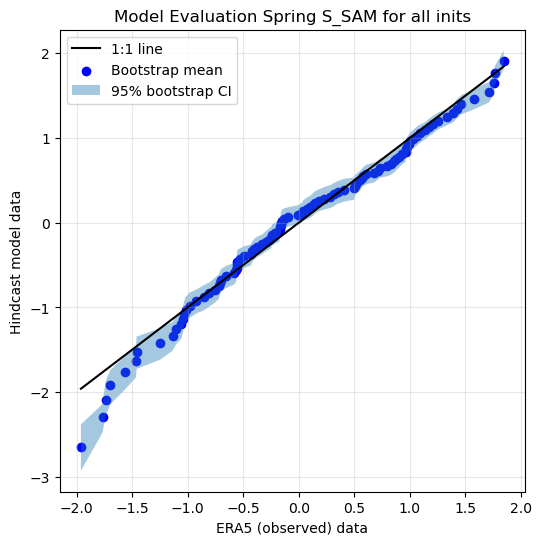

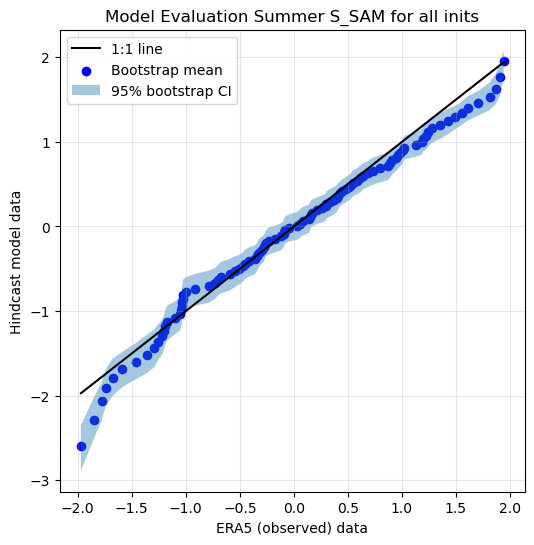

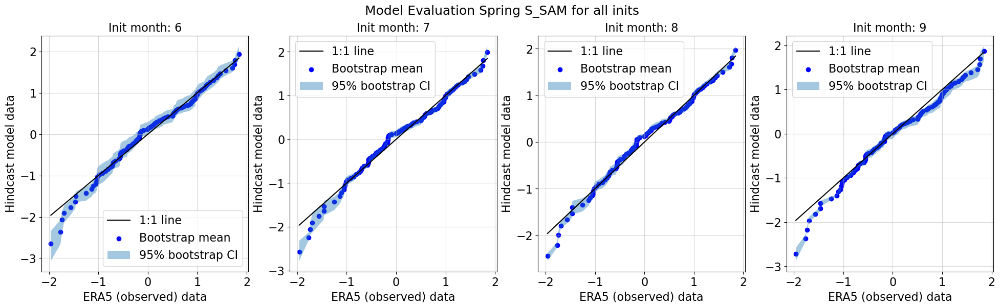

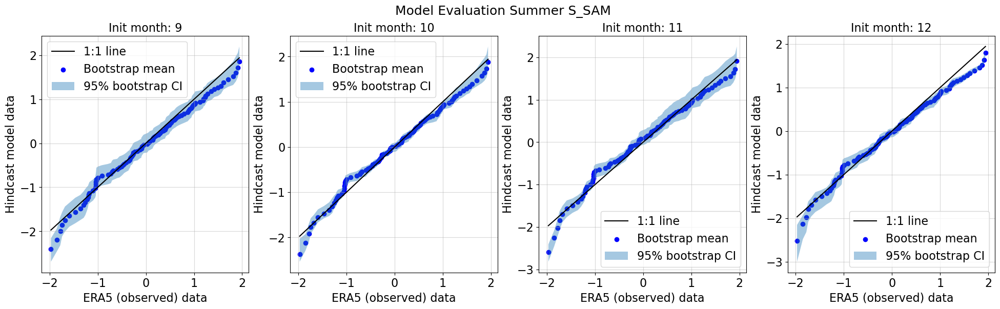

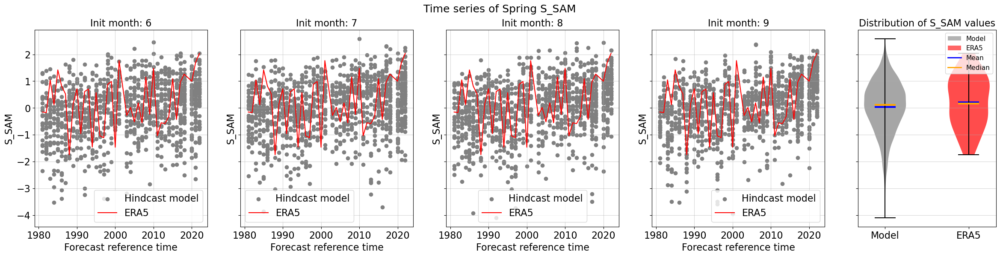

...

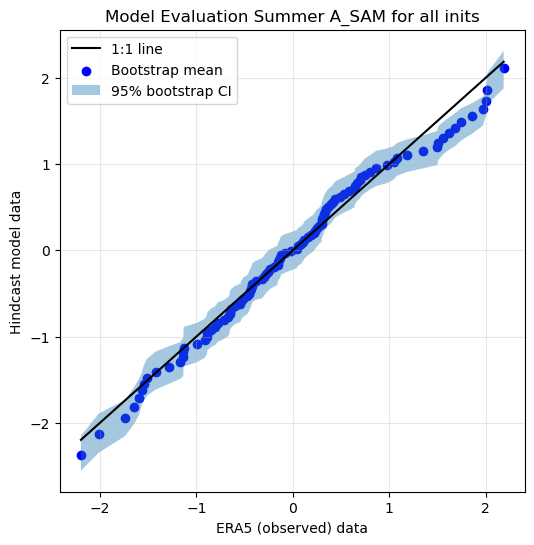

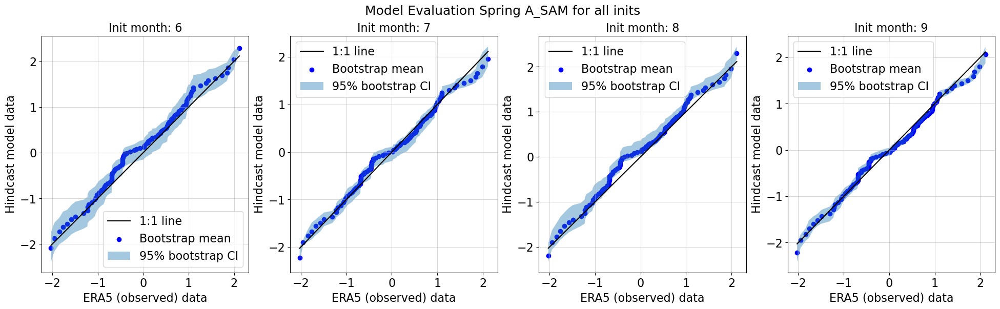

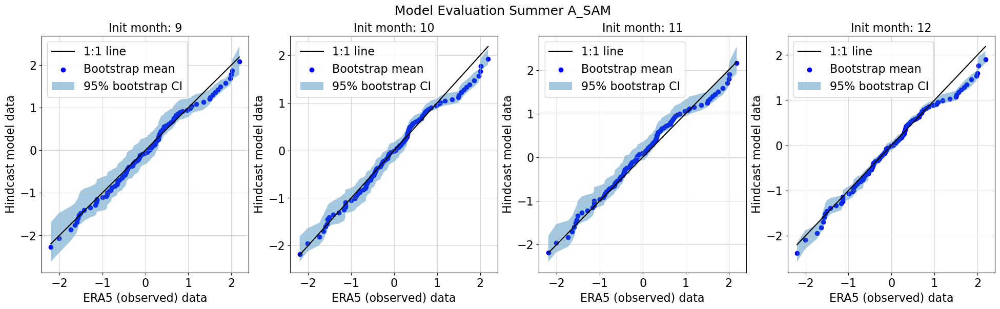

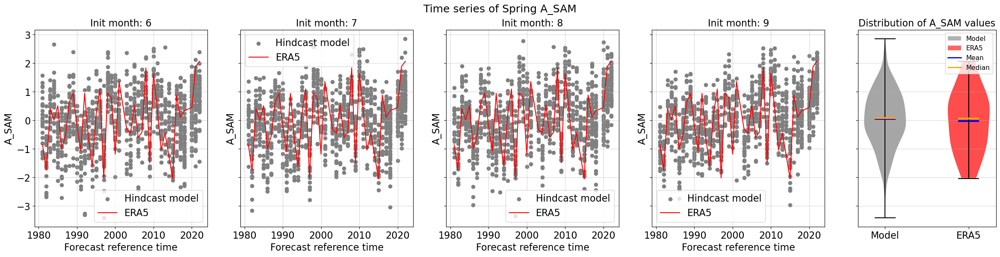

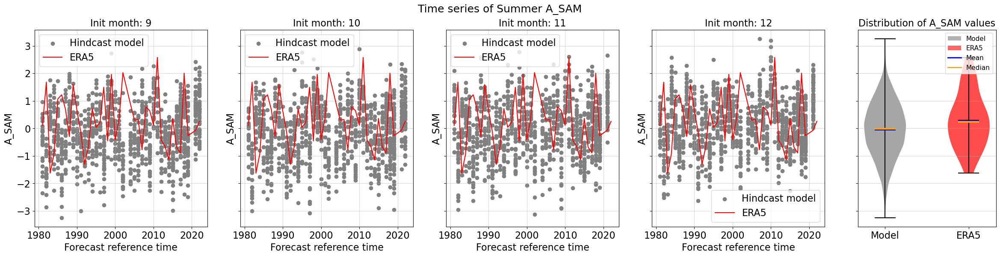

In [35]:
#separate init months
folder='Model_eval_plots/'
mapping = {
    list(ds_SAM_SON.data_vars)[0]: "S_SAM",
    list(ds_SAM_SON.data_vars)[1]: "A_SAM"}

months_list_SON=list(np.unique(ds_SAM_SON.init_month.values))
for var, era_var in mapping.items():
    #all init together
    a=bootstrap_chain(ds_SAM_SON, 1000, var=var)
        #print(np.shape(a))
    b=bootstrap_chain(ds_SAM_DJF, 1000, var=var)
    
    boot_perc_SAM_SON, era5_perc_SAM_SON, fig_whole=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                        input_title=f'Model Evaluation Spring {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)
    boot_perc_SAM_DJF, era5_perc_SAM_DJF, fig_whole=model_eval_plot(b, era5_array=era_DJF_LaPlata_array[era_var],
                                                        input_title=f'Model Evaluation Summer {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)

    #separated by init months
    a=bootstrap_chain(ds_SAM_SON, 1000, var=var, sep_lead=True)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 1000, var=var)

    boot_perc_SPV_SON, era5_perc_SPV_SON, fig_whole=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Spring {era_var} for all inits',
                                                    ds_init=ds_SAM_SON[var])
    fig_whole.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(ds_SAM_DJF, 1000, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Summer {era_var}',
                                                                ds_init=ds_SAM_DJF[var])
            
    fig_LP.savefig(folder+f'model_eval_summer_{era_var}_all_init.jpg', dpi=300)

    #time series
    fig_ts_SAM_SON=time_series_plot(ds_SAM_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                              input_title=f'Time series of Spring {era_var}')
    fig_ts_SAM_SON.savefig(folder+f'model_ts_spring_{era_var}.jpg', dpi=300)

    fig_ts_SAM_DJF=time_series_plot(ds_SAM_DJF[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                              input_title=f'Time series of Summer {era_var}')
    fig_ts_SAM_DJF.savefig(folder+f'model_ts_summer_{era_var}.jpg', dpi=300)
    
    